# Data Presentation and Visualisation Final Project - 2606019
## The Global Trends of Energy Efficiency and Its Role in Climate Change Mitigation


## i) Import Libraries

In [462]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import plotly.express as px
import geopandas as gpd
import os
import json

## ii) Data Cleaning

In [463]:
energy_raw = pd.read_csv('energyconsumption.csv', skiprows=1)
energy_raw.shape
energy_raw.head()

,API,Unnamed: 1,1980,1981,1982,1983,1984,1985,1986,1987,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,NaN,total energy consumption (quad Btu),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,INTL.44-2-AFG-QBTU.A,Afghanistan,0.02658321667756184,0.029949457623843767,0.031897814673808554,0.03902180313163165,0.03920224040186807,0.03827496129519434,0.039111198580053776,0.06306515769145625,...,0.13765027069319372,0.11416576977462783,0.09696120084250569,0.11172582624800645,0.10196781485590371,0.10086123775411128,0.11569819729775732,0.10343658619574822,0.09346919021295572,0.09258890712086146
2,INTL.44-2-ALB-QBTU.A,Albania,0.16298182182124926,0.16204449273682853,0.16284611700217974,0.16933585149179003,0.1704057218202433,0.17005625500667076,0.16607537777033485,0.1666405283961216,...,0.1051279333181231,0.13193111766441915,0.11621639284070061,0.11629730243544255,0.13589570519859817,0.12578047491234484,0.14342046025641697,0.1136090571488556,0.10914868032090533,0.137347715206226
3,INTL.44-2-DZA-QBTU.A,Algeria,0.7806951671133022,0.6633913232329025,0.952188115918025,1.0705618432163024,1.1307867129706235,1.0464182466677772,1.0663009617019872,1.1383186539191739,...,2.098203173382945,2.037584643437122,2.299888435758712,2.3521475403657623,2.3359823797283905,2.365986904617233,2.522119152162065,2.6248730961427658,2.4808107737143397,2.58112331407509
4,INTL.44-2-ASM-QBTU.A,American Samoa,0.0058931124,0.00692647725,0.0096550895,0.00608690425,0.0069454539,0.00650669075,0.006716584,0.0069730088735,...,0.004933530033037225,0.004930590895857226,0.004930528895857227,0.004930145088825,0.00495266140458,0.004957573895818638,0.004957028895818638,0.0049560338958186375,0.00472248254264,0.0054464101348


In [464]:
emissions_raw = pd.read_csv('emissions.csv', header=1)
emissions_raw.shape
emissions_raw.head(8)

,Series Key,INTL.4008-8-USOH-MMTCD.A,Series Key.1,INTL.4008-8-ARG-MMTCD.A,Series Key.2,INTL.4008-8-BEN-MMTCD.A,Series Key.3,INTL.4008-8-BHR-MMTCD.A,Series Key.4,INTL.4008-8-BRN-MMTCD.A,...,Series Key.225,INTL.4008-8-SOM-MMTCD.A,Series Key.226,INTL.4008-8-SYR-MMTCD.A,Series Key.227,INTL.4008-8-TUN-MMTCD.A,Series Key.228,INTL.4008-8-WSM-MMTCD.A,Series Key.229,INTL.4008-8-DEUW-MMTCD.A
0,Series Name,"CO2 emissions, U.S. Territories, Annual",Series Name,"CO2 emissions, Argentina, Annual",Series Name,"CO2 emissions, Benin, Annual",Series Name,"CO2 emissions, Bahrain, Annual",Series Name,"CO2 emissions, Brunei, Annual",...,Series Name,"CO2 emissions, Somalia, Annual",Series Name,"CO2 emissions, Syria, Annual",Series Name,"CO2 emissions, Tunisia, Annual",Series Name,"CO2 emissions, Samoa, Annual",Series Name,"CO2 emissions, Germany, West, Annual"
1,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD,...,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD
2,Frequency,A,Frequency,A,Frequency,A,Frequency,A,Frequency,A,...,Frequency,A,Frequency,A,Frequency,A,Frequency,A,Frequency,A
3,1980,0,1980,93,1980,0.4,1980,7.8,1980,4.5,...,1980,1.1,1980,16,1980,8.5,1980,(s),1980,736
4,1981,0,1981,91,1981,0.4,1981,8.9,1981,4.7,...,1981,1.3,1981,17,1981,9.3,1981,(s),1981,691
5,1982,0,1982,94,1982,0.3,1982,9.3,1982,5,...,1982,1.3,1982,17,1982,8.7,1982,0.1,1982,686
6,1983,0,1983,94,1983,0.4,1983,9.9,1983,4,...,1983,1.2,1983,20,1983,10,1983,0.1,1983,681
7,1984,0,1984,98,1984,0.4,1984,9.6,1984,3.6,...,1984,1.3,1984,22,1984,11,1984,0.1,1984,705


In [465]:
xls = pd.ExcelFile('pwt1001.xlsx')
print(xls.sheet_names)

['Info', 'Legend', 'Data']


In [466]:
pwt_raw = pd.read_excel('pwt1001.xlsx', sheet_name='Data')
pwt_raw.shape
pwt_raw.head()

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
0,ABW,Aruba,Aruban Guilder,1950,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ABW,Aruba,Aruban Guilder,1951,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ABW,Aruba,Aruban Guilder,1952,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,Aruba,Aruban Guilder,1953,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,Aruba,Aruban Guilder,1954,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [467]:
with open('world-countries.json') as f:
    world_geo = json.load(f)

In [468]:
xls = pd.ExcelFile('epc_lad_april2020_march2021.xlsx')
print(xls.sheet_names)

['Table1', 'Table2']


In [469]:
xls = pd.ExcelFile('epc_lad_april2021_march2022.xlsx')
print(xls.sheet_names)

['Table1', 'Table2']


In [470]:
epc_2021_t1 = pd.read_excel('epc_lad_april2020_march2021.xlsx', sheet_name='Table1', header=3)
epc_2021_t2 = pd.read_excel('epc_lad_april2020_march2021.xlsx', sheet_name='Table2', header=3)
epc_2022_t1 = pd.read_excel('epc_lad_april2021_march2022.xlsx', sheet_name='Table1', header=3)
epc_2022_t2 = pd.read_excel('epc_lad_april2021_march2022.xlsx', sheet_name='Table2', header=3)
epc_2021_t1

,Region code,Region name,Local authority district code,Local authority district name,All dwellings
0,E12000001,North East,E06000001,Hartlepool,66
1,E12000001,North East,E06000002,Middlesbrough,67
2,E12000001,North East,E06000003,Redcar and Cleveland,65
3,E12000001,North East,E06000004,Stockton-on-Tees,67
4,E12000001,North East,E06000005,Darlington,65
...,...,...,...,...,...
326,W92000004,Wales,W06000020,Torfaen,67
327,W92000004,Wales,W06000021,Monmouthshire,66
328,W92000004,Wales,W06000022,Newport,68
329,W92000004,Wales,W06000023,Powys,61


In [471]:
lad_geo1 = gpd.read_file('ew_lad2023_1.json')
lad_geo2 = gpd.read_file('ew_lad2023_2.json')
lad_geo = pd.concat([lad_geo1, lad_geo2], ignore_index=True)
lad_geo.shape
lad_geo.head()

,FID,LAD23CD,LAD23NM,LAD23NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,geometry
0,1,E06000001,Hartlepool,,447160,531474,-1.27018,54.67614,ed77cf59-0f99-40ee-8ce0-3c495b0436dd,"MULTIPOLYGON (((-1.2247 54.62611, -1.22493 54...."
1,2,E06000002,Middlesbrough,,451141,516887,-1.21099,54.54467,12aebc50-49df-4d0f-af2e-7b18e5928ad7,"MULTIPOLYGON (((-1.2772 54.54784, -1.27721 54...."
2,3,E06000003,Redcar and Cleveland,,464361,519597,-1.00608,54.56752,b073197d-76d1-468b-a1ca-e71a9465fc1e,"MULTIPOLYGON (((-1.20098 54.57763, -1.2003 54...."
3,4,E06000004,Stockton-on-Tees,,444940,518179,-1.30664,54.55687,a722dfde-1ff3-4a0c-90e7-4b7cc413ba49,"MULTIPOLYGON (((-1.27211 54.55337, -1.27213 54..."
4,5,E06000005,Darlington,,428029,515648,-1.56835,54.53534,7341c0fb-23f7-4180-9f8f-f11c67107389,"POLYGON ((-1.63768 54.61714, -1.63767 54.6167,..."


In [472]:
gdp_pc_raw   = pd.read_csv('gdp_per_capita.csv', skiprows=4)
industry_raw = pd.read_csv('industry_values.csv', skiprows=4)
trade_raw    = pd.read_csv('trade_values.csv', skiprows=4)
renewables_raw = pd.read_csv('renewable_energy.csv', skiprows=4)

In [473]:
gdp_pc_raw

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
0,Aruba,ABW,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,28548.890432,29419.208623,29699.180537,22729.889759,26292.917936,29195.267023,31430.935368,33373.917459,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1186.349620,1160.458789,1219.356473,1253.445317,1275.886801,1304.275651,...,1490.911098,1489.942137,1479.372387,1399.398498,1425.209057,1440.430366,1431.721790,1435.356278,NaN,NaN
2,Afghanistan,AFG,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,562.769574,553.125152,557.861533,527.834554,408.625855,377.665627,378.066303,NaN,NaN,NaN
3,Africa Western and Central,AFW,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1130.411973,1127.572551,1144.920732,1199.197534,1236.216308,1258.758091,...,1808.722201,1814.694636,1829.068064,1719.261504,1721.909475,1757.456590,1778.864347,1816.346044,NaN,NaN
4,Angola,AGO,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,3328.898212,3196.790070,3083.975344,2864.161460,2832.817771,2860.902519,2809.157280,2845.477793,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,3890.178073,4009.121408,4219.066939,3990.946131,4429.875975,4666.391378,5102.749146,5631.682234,NaN,NaN
262,"Yemen, Rep.",YEM,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,1103.456348,1079.329384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
263,South Africa,ZAF,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,3993.436797,4032.222725,4155.857115,4329.073920,4532.234305,4664.096991,...,6125.692051,6117.270141,6032.829726,5569.584833,5750.909375,5786.865053,5756.550495,5715.475315,NaN,NaN
264,Zambia,ZMB,GDP per capita (constant 2015 US$),NY.GDP.PCAP.KD,1187.704601,1166.745964,1102.445822,1103.108132,1199.392190,1355.456810,...,1308.768292,1321.250457,1301.181330,1228.735001,1269.108218,1298.848050,1330.859982,1343.389664,NaN,NaN


In [474]:
print(gdp_pc_raw.shape)
print(industry_raw.shape)
print(trade_raw.shape)
print(renewables_raw.shape)

(266, 71)
(266, 71)
(266, 71)
(266, 71)


In [475]:
def reshape_wb(df, value_name):
  """Reshape the World Bank data to long format."""
  year_cols = [c for c in df.columns if str(c).strip().isdigit()]
  df_long = df[['Country Name', 'Country Code'] + year_cols].melt(
        id_vars=['Country Name', 'Country Code'],
        var_name='year',
        value_name=value_name
  )
  df_long['year'] = df_long['year'].astype(int)
  df_long[value_name] = pd.to_numeric(df_long[value_name], errors='coerce')
  df_long = df_long[df_long['year'].between(1980, 2019)]
  df_long.rename(columns={'Country Name': 'country_name',
                            'Country Code': 'country_code'}, inplace=True)
  return df_long

gdp_pc = reshape_wb(gdp_pc_raw, 'gdp_per_capita')
industry = reshape_wb(industry_raw, 'industry_share_gdp')
trade = reshape_wb(trade_raw, 'trade_openness')
renewables = reshape_wb(renewables_raw, 'renewables_share')

In [476]:
gdp_pc

,country_name,country_code,year,gdp_per_capita
5320,Aruba,ABW,1980,NaN
5321,Africa Eastern and Southern,AFE,1980,1423.113038
5322,Afghanistan,AFG,1980,NaN
5323,Africa Western and Central,AFW,1980,1603.202278
5324,Angola,AGO,1980,3186.739597
...,...,...,...,...
15955,Kosovo,XKX,2019,4219.066939
15956,"Yemen, Rep.",YEM,2019,NaN
15957,South Africa,ZAF,2019,6032.829726
15958,Zambia,ZMB,2019,1301.181330


In [477]:
print(gdp_pc.shape)
print(industry.shape)
print(trade.shape)
print(renewables.shape)

(10640, 4)
(10640, 4)
(10640, 4)
(10640, 4)


In [478]:
wb_df = gdp_pc.merge(industry[['country_code', 'year', 'industry_share_gdp']],
                     on=['country_code', 'year'], how='outer')
wb_df = wb_df.merge(trade[['country_code', 'year', 'trade_openness']],
                    on=['country_code', 'year'], how='outer')
wb_df = wb_df.merge(renewables[['country_code', 'year', 'renewables_share']],
                    on=['country_code', 'year'], how='outer')

In [479]:
wb_df

,country_name,country_code,year,gdp_per_capita,industry_share_gdp,trade_openness,renewables_share
0,Aruba,ABW,1980,NaN,NaN,NaN,NaN
1,Aruba,ABW,1981,NaN,NaN,NaN,NaN
2,Aruba,ABW,1982,NaN,NaN,NaN,NaN
3,Aruba,ABW,1983,NaN,NaN,NaN,NaN
4,Aruba,ABW,1984,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...
10635,Zimbabwe,ZWE,2015,1387.126326,22.358655,56.749653,80.8
10636,Zimbabwe,ZWE,2016,1378.342562,22.115350,51.219038,81.7
10637,Zimbabwe,ZWE,2017,1422.919489,32.015738,55.028318,82.0
10638,Zimbabwe,ZWE,2018,1472.146038,31.037775,54.550317,79.7


In [480]:
energy_raw.rename(columns={'API': 'country_code', 'Unnamed: 1': 'country_name'}, inplace=True)
energy_raw.head()

,country_code,country_name,1980,1981,1982,1983,1984,1985,1986,1987,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,NaN,total energy consumption (quad Btu),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,INTL.44-2-AFG-QBTU.A,Afghanistan,0.02658321667756184,0.029949457623843767,0.031897814673808554,0.03902180313163165,0.03920224040186807,0.03827496129519434,0.039111198580053776,0.06306515769145625,...,0.13765027069319372,0.11416576977462783,0.09696120084250569,0.11172582624800645,0.10196781485590371,0.10086123775411128,0.11569819729775732,0.10343658619574822,0.09346919021295572,0.09258890712086146
2,INTL.44-2-ALB-QBTU.A,Albania,0.16298182182124926,0.16204449273682853,0.16284611700217974,0.16933585149179003,0.1704057218202433,0.17005625500667076,0.16607537777033485,0.1666405283961216,...,0.1051279333181231,0.13193111766441915,0.11621639284070061,0.11629730243544255,0.13589570519859817,0.12578047491234484,0.14342046025641697,0.1136090571488556,0.10914868032090533,0.137347715206226
3,INTL.44-2-DZA-QBTU.A,Algeria,0.7806951671133022,0.6633913232329025,0.952188115918025,1.0705618432163024,1.1307867129706235,1.0464182466677772,1.0663009617019872,1.1383186539191739,...,2.098203173382945,2.037584643437122,2.299888435758712,2.3521475403657623,2.3359823797283905,2.365986904617233,2.522119152162065,2.6248730961427658,2.4808107737143397,2.58112331407509
4,INTL.44-2-ASM-QBTU.A,American Samoa,0.0058931124,0.00692647725,0.0096550895,0.00608690425,0.0069454539,0.00650669075,0.006716584,0.0069730088735,...,0.004933530033037225,0.004930590895857226,0.004930528895857227,0.004930145088825,0.00495266140458,0.004957573895818638,0.004957028895818638,0.0049560338958186375,0.00472248254264,0.0054464101348


In [481]:
def reshape_energy(df, value_name):
  """Reshape the energy data to long format."""
  year_cols = [c for c in df.columns if str(c).strip().isdigit()]
  df_long = df[['country_code', 'country_name'] + year_cols].melt(
        id_vars=['country_code', 'country_name'],
        var_name='year',
        value_name=value_name
  )
  df_long['year'] = df_long['year'].astype(int)
  df_long[value_name] = pd.to_numeric(df_long[value_name], errors='coerce')
  df_long = df_long[df_long['year'].between(1980, 2019)]
  df_long['country_code'] = df_long['country_code'].str.replace("INTL.44-2-", "").str.replace("-QBTU.A", "").str.strip()
  return df_long

energy = reshape_energy(energy_raw, 'energy_consumption')

In [482]:
energy = energy.dropna(subset=['energy_consumption'])
energy['country_name'] = energy['country_name'].str.strip()
energy

,country_code,country_name,year,energy_consumption
1,AFG,Afghanistan,1980,0.026583
2,ALB,Albania,1980,0.162982
3,DZA,Algeria,1980,0.780695
4,ASM,American Samoa,1980,0.005893
5,AGO,Angola,1980,0.058366
...,...,...,...,...
9235,WAK,Wake Island,2019,0.019436
9236,ESH,Western Sahara,2019,0.003712
9237,YEM,Yemen,2019,0.158878
9238,ZMB,Zambia,2019,0.187139


In [483]:
emissions_raw

,Series Key,INTL.4008-8-USOH-MMTCD.A,Series Key.1,INTL.4008-8-ARG-MMTCD.A,Series Key.2,INTL.4008-8-BEN-MMTCD.A,Series Key.3,INTL.4008-8-BHR-MMTCD.A,Series Key.4,INTL.4008-8-BRN-MMTCD.A,...,Series Key.225,INTL.4008-8-SOM-MMTCD.A,Series Key.226,INTL.4008-8-SYR-MMTCD.A,Series Key.227,INTL.4008-8-TUN-MMTCD.A,Series Key.228,INTL.4008-8-WSM-MMTCD.A,Series Key.229,INTL.4008-8-DEUW-MMTCD.A
0,Series Name,"CO2 emissions, U.S. Territories, Annual",Series Name,"CO2 emissions, Argentina, Annual",Series Name,"CO2 emissions, Benin, Annual",Series Name,"CO2 emissions, Bahrain, Annual",Series Name,"CO2 emissions, Brunei, Annual",...,Series Name,"CO2 emissions, Somalia, Annual",Series Name,"CO2 emissions, Syria, Annual",Series Name,"CO2 emissions, Tunisia, Annual",Series Name,"CO2 emissions, Samoa, Annual",Series Name,"CO2 emissions, Germany, West, Annual"
1,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD,...,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD,Units,MMTCD
2,Frequency,A,Frequency,A,Frequency,A,Frequency,A,Frequency,A,...,Frequency,A,Frequency,A,Frequency,A,Frequency,A,Frequency,A
3,1980,0,1980,93,1980,0.4,1980,7.8,1980,4.5,...,1980,1.1,1980,16,1980,8.5,1980,(s),1980,736
4,1981,0,1981,91,1981,0.4,1981,8.9,1981,4.7,...,1981,1.3,1981,17,1981,9.3,1981,(s),1981,691
5,1982,0,1982,94,1982,0.3,1982,9.3,1982,5,...,1982,1.3,1982,17,1982,8.7,1982,0.1,1982,686
6,1983,0,1983,94,1983,0.4,1983,9.9,1983,4,...,1983,1.2,1983,20,1983,10,1983,0.1,1983,681
7,1984,0,1984,98,1984,0.4,1984,9.6,1984,3.6,...,1984,1.3,1984,22,1984,11,1984,0.1,1984,705
8,1985,0,1985,92,1985,0.5,1985,11,1985,4.3,...,1985,1.3,1985,23,1985,11,1985,0.1,1985,726
9,1986,0,1986,104,1986,0.5,1986,12,1986,2.8,...,1986,1.4,1986,24,1986,12,1986,0.1,1986,751


In [484]:
def reshape_emissions(df, value_name):
  """Reshape the emissions data to long format."""
  series_data_cols = df.columns[1::2]
  all_reshaped_data = []

  years = pd.to_numeric(df['Series Key'].iloc[3:], errors='coerce')

  for series_id_col in series_data_cols:
    series_name = df.loc[0, series_id_col]

    country_name = series_name.replace("CO2 emissions, ", "").replace(", Annual", "").strip()
    country_code = series_id_col.replace("INTL.4008-8-", "").replace("-MMTCD.A", "").strip()

    co2_emissions = pd.to_numeric(df[series_id_col].iloc[3:], errors='coerce')

    temp_df = pd.DataFrame({
        'country_code': country_code,
        'country_name': country_name,
        'year': years,
        value_name: co2_emissions
    })
    all_reshaped_data.append(temp_df)

  df_long = pd.concat(all_reshaped_data, ignore_index=True)
  df_long = df_long[df_long['year'].between(1980, 2019)]
  df_long = df_long.dropna(subset=[value_name])

  return df_long

emissions = reshape_emissions(emissions_raw, 'co2_emissions')

In [485]:
emissions

,country_code,country_name,year,co2_emissions
0,USOH,U.S. Territories,1980,0.0
1,USOH,U.S. Territories,1981,0.0
2,USOH,U.S. Territories,1982,0.0
3,USOH,U.S. Territories,1983,0.0
4,USOH,U.S. Territories,1984,0.0
...,...,...,...,...
9624,DEUW,"Germany, West",1986,751.0
9625,DEUW,"Germany, West",1987,745.0
9626,DEUW,"Germany, West",1988,735.0
9627,DEUW,"Germany, West",1989,721.0


In [486]:
pwt_keep = [c for c in ['countrycode', 'country', 'year', 'rgdpo', 'pop', 'emp', 'hc']
            if c in pwt_raw.columns]
pwt = pwt_raw[pwt_keep].copy()
pwt = pwt[pwt['year'].between(1980, 2019)]
pwt.rename(columns={'rgdpo': 'gdp', 'country': 'country_name', 'countrycode': 'country_code'}, inplace=True)

In [487]:
pwt

,country_code,country_name,year,gdp,pop,emp,hc
30,ABW,Aruba,1980,1097.319336,0.060096,NaN,NaN
31,ABW,Aruba,1981,1197.645630,0.060567,NaN,NaN
32,ABW,Aruba,1982,1306.708252,0.061345,NaN,NaN
33,ABW,Aruba,1983,1425.281616,0.062201,NaN,NaN
34,ABW,Aruba,1984,1555.416870,0.062836,NaN,NaN
...,...,...,...,...,...,...,...
12805,ZWE,Zimbabwe,2015,39798.644531,13.814629,6.393752,2.584653
12806,ZWE,Zimbabwe,2016,40963.191406,14.030331,6.504374,2.616257
12807,ZWE,Zimbabwe,2017,44316.742188,14.236595,6.611773,2.648248
12808,ZWE,Zimbabwe,2018,43420.898438,14.438802,6.714952,2.680630


In [488]:
global_df = energy.merge(emissions, on=['country_code', 'year'], how='inner')
global_df = global_df.merge(pwt, on=['country_code', 'year'], how='inner')
global_df.drop(columns=['country_name_y', 'country_name'], inplace=True)
global_df.rename(columns={'country_name_x': 'country_name'}, inplace=True)

In [489]:
global_df

,country_code,country_name,year,energy_consumption,co2_emissions,gdp,pop,emp,hc
0,ALB,Albania,1980,0.162982,9.6,9964.961914,2.682690,1.027045,1.881057
1,DZA,Algeria,1980,0.780695,46.0,235556.593750,19.221665,3.325097,1.252473
2,AGO,Angola,1980,0.058366,3.4,28927.419922,8.341289,4.952234,1.041064
3,ATG,Antigua and Barbuda,1980,0.005805,0.4,492.558044,0.061865,NaN,NaN
4,ARG,Argentina,1980,1.713088,93.0,125315.265625,27.896528,9.828572,2.250048
...,...,...,...,...,...,...,...,...,...
6612,VEN,Venezuela,2019,2.115667,97.0,7160.106934,28.515829,11.694400,2.893462
6613,VNM,Vietnam,2019,4.051460,292.0,724123.375000,96.462106,50.399563,2.869998
6614,YEM,Yemen,2019,0.158878,10.0,51828.058594,29.161922,5.531877,1.842989
6615,ZMB,Zambia,2019,0.187139,6.0,56783.714844,17.861030,5.225448,2.686845


In [490]:
global_df['eei'] = global_df['energy_consumption'] / global_df['gdp'] * 1000000
global_df['gdp_per_capita'] = global_df['gdp'] / global_df['pop']
global_df['decade'] = (global_df['year'] // 10) * 10

In [491]:
global_df

,country_code,country_name,year,energy_consumption,co2_emissions,gdp,pop,emp,hc,eei,gdp_per_capita,decade
0,ALB,Albania,1980,0.162982,9.6,9964.961914,2.682690,1.027045,1.881057,16.355489,3714.540970,1980
1,DZA,Algeria,1980,0.780695,46.0,235556.593750,19.221665,3.325097,1.252473,3.314257,12254.744516,1980
2,AGO,Angola,1980,0.058366,3.4,28927.419922,8.341289,4.952234,1.041064,2.017676,3467.979580,1980
3,ATG,Antigua and Barbuda,1980,0.005805,0.4,492.558044,0.061865,NaN,NaN,11.785120,7961.820810,1980
4,ARG,Argentina,1980,1.713088,93.0,125315.265625,27.896528,9.828572,2.250048,13.670227,4492.145604,1980
...,...,...,...,...,...,...,...,...,...,...,...,...
6612,VEN,Venezuela,2019,2.115667,97.0,7160.106934,28.515829,11.694400,2.893462,295.479769,251.092365,2010
6613,VNM,Vietnam,2019,4.051460,292.0,724123.375000,96.462106,50.399563,2.869998,5.594986,7506.816977,2010
6614,YEM,Yemen,2019,0.158878,10.0,51828.058594,29.161922,5.531877,1.842989,3.065476,1777.251122,2010
6615,ZMB,Zambia,2019,0.187139,6.0,56783.714844,17.861030,5.225448,2.686845,3.295654,3179.195984,2010


In [492]:
global_df = global_df.merge(
    wb_df[['country_code', 'year', 'gdp_per_capita', 'industry_share_gdp',
                 'trade_openness', 'renewables_share']],
    left_on=['country_code', 'year'],
    right_on=['country_code', 'year'],
    how='left'
)

In [493]:
global_df.drop(columns=['gdp_per_capita_x'], inplace=True)
global_df.rename(columns={'gdp_per_capita_y': 'gdp_per_capita'}, inplace=True)

In [494]:
global_df.dropna(subset=['eei', 'gdp', 'energy_consumption', 'co2_emissions'], inplace=True)
global_df['country_name'] = global_df['country_name'].replace({
    'Republic of Korea': 'South Korea'
})
for col in ['eei', 'gdp_per_capita', 'co2_emissions']:
    if col in global_df.columns:
        global_df[f'log_{col}'] = np.log(global_df[col].replace(0, np.nan))
global_df

,country_code,country_name,year,energy_consumption,co2_emissions,gdp,pop,emp,hc,eei,decade,gdp_per_capita,industry_share_gdp,trade_openness,renewables_share,log_eei,log_gdp_per_capita,log_co2_emissions
0,ALB,Albania,1980,0.162982,9.6,9964.961914,2.682690,1.027045,1.881057,16.355489,1980,1823.489260,NaN,47.494093,NaN,2.794564,7.508507,2.261763
1,DZA,Algeria,1980,0.780695,46.0,235556.593750,19.221665,3.325097,1.252473,3.314257,1980,3742.710247,NaN,64.676923,NaN,1.198234,8.227565,3.828641
2,AGO,Angola,1980,0.058366,3.4,28927.419922,8.341289,4.952234,1.041064,2.017676,1980,3186.739597,NaN,NaN,NaN,0.701946,8.066754,1.223775
3,ATG,Antigua and Barbuda,1980,0.005805,0.4,492.558044,0.061865,NaN,NaN,11.785120,1980,7323.125855,12.887982,NaN,NaN,2.466838,8.898793,-0.916291
4,ARG,Argentina,1980,1.713088,93.0,125315.265625,27.896528,9.828572,2.250048,13.670227,1980,10275.798702,41.219666,11.545672,NaN,2.615220,9.237547,4.532599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6612,VEN,Venezuela,2019,2.115667,97.0,7160.106934,28.515829,11.694400,2.893462,295.479769,2010,1762.737348,NaN,58.129290,15.8,5.688600,7.474623,4.574711
6613,VNM,Vietnam,2019,4.051460,292.0,724123.375000,96.462106,50.399563,2.869998,5.594986,2010,3241.076490,36.803137,164.704215,20.4,1.721871,8.083661,5.676754
6614,YEM,Yemen,2019,0.158878,10.0,51828.058594,29.161922,5.531877,1.842989,3.065476,2010,NaN,NaN,NaN,3.0,1.120203,NaN,2.302585
6615,ZMB,Zambia,2019,0.187139,6.0,56783.714844,17.861030,5.225448,2.686845,3.295654,2010,1301.181330,34.941981,68.791205,86.1,1.192605,7.171028,1.791759


In [495]:
global_df['country_name'].unique()

array(['Albania', 'Algeria', 'Angola', 'Antigua and Barbuda', 'Argentina',
       'Australia', 'Austria', 'Bahrain', 'Bangladesh', 'Barbados',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bolivia', 'Botswana',
       'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burma',
       'Cabo Verde', 'Cameroon', 'Canada', 'Central African Republic',
       'Chad', 'Chile', 'China', 'Colombia', 'Congo-Brazzaville',
       'Congo-Kinshasa', 'Costa Rica', "Cote d'Ivoire", 'Cyprus',
       'Denmark', 'Djibouti', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France',
       'Gabon', 'Gambia, The', 'Ghana', 'Greece', 'Guatemala', 'Guinea',
       'Guyana', 'Haiti', 'Honduras', 'Hong Kong', 'Hungary', 'Iceland',
       'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Italy',
       'Jamaica', 'Japan', 'Jordan', 'Kenya', 'Kuwait', 'Laos', 'Lebanon',
       'Lesotho', 'Liberia', 'Luxembourg', 'Macau', 'Madagascar',
       'Ma

In [496]:
developed = [
    'Germany', 'France', 'United Kingdom', 'Norway', 'Sweden',
    'Poland', 'Romania', 'Japan', 'South Korea', 'Singapore',
    'Australia', 'New Zealand', 'United States', 'Canada'
]

developing = [
    'Albania', 'Serbia', 'China', 'India', 'Indonesia',
    'Thailand', 'Brazil', 'Mexico', 'Colombia', 'Chile',
    'South Africa', 'Morocco', 'Kenya', 'Nigeria'
]

In [497]:
all_countries = developed + developing

In [498]:
global_df = global_df[global_df['country_name'].isin(all_countries)].copy()

In [499]:
global_df['development_status'] = np.where(
    global_df['country_name'].isin(developed), 'Developed', 'Developing'
)

In [500]:
global_df

,country_code,country_name,year,energy_consumption,co2_emissions,gdp,pop,emp,hc,eei,decade,gdp_per_capita,industry_share_gdp,trade_openness,renewables_share,log_eei,log_gdp_per_capita,log_co2_emissions,development_status
0,ALB,Albania,1980,0.162982,9.6,9.964962e+03,2.682690,1.027045,1.881057,16.355489,1980,1823.489260,NaN,47.494093,NaN,2.794564,7.508507,2.261763,Developing
5,AUS,Australia,1980,2.985436,221.0,3.602264e+05,14.588405,6.277514,3.213360,8.287665,1980,30796.999074,NaN,32.252513,NaN,2.114768,10.335173,5.398163,Developed
16,BRA,Brazil,1980,3.896381,188.0,7.093135e+05,120.694009,43.310600,1.481538,5.493172,1980,6472.851401,43.972540,20.155407,NaN,1.703506,8.775372,5.236442,Developing
23,CAN,Canada,1980,9.587301,426.0,6.879111e+05,24.416886,11.080690,3.085586,13.936832,1980,27622.373403,NaN,53.317976,NaN,2.634535,10.226381,6.054439,Developed
26,CHL,Chile,1980,0.427184,22.0,8.343044e+04,11.419348,3.161922,2.385696,5.120245,1980,4627.193491,36.603392,47.225557,NaN,1.633202,8.439706,3.091042,Developing
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6586,KOR,South Korea,2019,12.388879,687.0,2.162705e+06,51.225308,26.798534,3.765123,5.728418,2010,33496.311382,33.646492,71.447063,3.2,1.745439,10.419191,6.532334,Developed
6591,SWE,Sweden,2019,2.168105,48.0,5.262408e+05,10.036379,5.002137,3.435986,4.119986,2010,53024.409949,22.376071,92.751139,52.9,1.415850,10.878508,3.871201,Developed
6597,THA,Thailand,2019,5.392705,308.0,1.191733e+06,69.625582,37.540958,2.804449,4.525095,2010,6434.537705,33.593911,109.689515,23.9,1.509639,8.769435,5.730100,Developing
6608,GBR,United Kingdom,2019,7.978276,392.0,2.989896e+06,67.530172,32.982498,3.773596,2.668413,2010,47864.758871,17.873634,65.003566,11.4,0.981484,10.776135,5.971262,Developed


In [501]:
def clean_epc(df, period_label):
    df = df.copy()
    df.columns = (df.columns.astype(str)
                    .str.strip()
                    .str.lower()
                    .str.replace(r'\s+', '_', regex=True)
                    .str.replace(r'[^\w]', '', regex=True))
    df['period'] = period_label
    df.dropna(how='all', inplace=True)
    return df

epc_2021_t1 = clean_epc(epc_2021_t1, '2020-21')
epc_2021_t2 = clean_epc(epc_2021_t2, '2020-21')
epc_2022_t1 = clean_epc(epc_2022_t1, '2021-22')
epc_2022_t2 = clean_epc(epc_2022_t2, '2021-22')

In [502]:
print(epc_2021_t1.shape)
print(epc_2021_t2.shape)
print(epc_2022_t1.shape)
print(epc_2022_t2.shape)

(331, 6)
(331, 6)
(331, 6)
(331, 6)


In [503]:
epc_ee = pd.concat([epc_2021_t1, epc_2022_t1], ignore_index=True)
epc_ei = pd.concat([epc_2021_t2, epc_2022_t2], ignore_index=True)

In [504]:
print("EPC EE columns:", epc_ee.columns.tolist())
print("LAD geo columns:", lad_geo.columns.tolist())

EPC EE columns: ['region_code', 'region_name', 'local_authority_district_code', 'local_authority_district_name', 'all_dwellings', 'period']
LAD geo columns: ['FID', 'LAD23CD', 'LAD23NM', 'LAD23NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT', 'GlobalID', 'geometry']


In [505]:
epc_ee.rename(columns={'all_dwellings': 'energy_efficiency_score'}, inplace=True)
epc_ei.rename(columns={'all_dwellings': 'environmental_impact_score'}, inplace=True)
print(epc_ee.shape)
epc_ee.head()

(662, 6)


,region_code,region_name,local_authority_district_code,local_authority_district_name,energy_efficiency_score,period
0,E12000001,North East,E06000001,Hartlepool,66,2020-21
1,E12000001,North East,E06000002,Middlesbrough,67,2020-21
2,E12000001,North East,E06000003,Redcar and Cleveland,65,2020-21
3,E12000001,North East,E06000004,Stockton-on-Tees,67,2020-21
4,E12000001,North East,E06000005,Darlington,65,2020-21


In [506]:
lad_geo = lad_geo.rename(columns={'LAD23CD': 'local_authority_district_code', 'LAD23NM': 'local_authority_district_name'})

In [507]:
regional_df = epc_ee.merge(
    epc_ei[['local_authority_district_code', 'period', 'environmental_impact_score']],
    on=['local_authority_district_code', 'period'],
    how='left'
)
regional_df = lad_geo.merge(
    regional_df,
    on='local_authority_district_code',
    how='left'
)

In [508]:
regional_df.drop(columns=['local_authority_district_name_y'], inplace=True)

In [509]:
regional_df.rename(columns={'local_authority_district_name_x': 'local_authority_district_name',
                            'LAD23NMW': 'local_authority_district_welsh_name',
                            'LONG': 'Long',
                            'LAT': 'Lat'}, inplace=True)
regional_df

,FID,local_authority_district_code,local_authority_district_name,local_authority_district_welsh_name,BNG_E,BNG_N,Long,Lat,GlobalID,geometry,region_code,region_name,energy_efficiency_score,period,environmental_impact_score
0,1,E06000001,Hartlepool,,447160,531474,-1.27018,54.67614,ed77cf59-0f99-40ee-8ce0-3c495b0436dd,"MULTIPOLYGON (((-1.2247 54.62611, -1.22493 54....",E12000001,North East,66.0,2020-21,64.0
1,1,E06000001,Hartlepool,,447160,531474,-1.27018,54.67614,ed77cf59-0f99-40ee-8ce0-3c495b0436dd,"MULTIPOLYGON (((-1.2247 54.62611, -1.22493 54....",E12000001,North East,66.0,2021-22,64.0
2,2,E06000002,Middlesbrough,,451141,516887,-1.21099,54.54467,12aebc50-49df-4d0f-af2e-7b18e5928ad7,"MULTIPOLYGON (((-1.2772 54.54784, -1.27721 54....",E12000001,North East,67.0,2020-21,65.0
3,2,E06000002,Middlesbrough,,451141,516887,-1.21099,54.54467,12aebc50-49df-4d0f-af2e-7b18e5928ad7,"MULTIPOLYGON (((-1.2772 54.54784, -1.27721 54....",E12000001,North East,67.0,2021-22,64.0
4,3,E06000003,Redcar and Cleveland,,464361,519597,-1.00608,54.56752,b073197d-76d1-468b-a1ca-e71a9465fc1e,"MULTIPOLYGON (((-1.20098 54.57763, -1.2003 54....",E12000001,North East,65.0,2020-21,62.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,359,W06000022,Newport,Casnewydd,337897,187432,-2.89769,51.58231,f3bf10e2-5a9e-465d-a8a6-e1c3e1aa187d,"MULTIPOLYGON (((-2.95223 51.62897, -2.952 51.6...",W92000004,Wales,68.0,2021-22,65.0
628,360,W06000023,Powys,Powys,302329,273254,-3.43531,52.34863,9da0c14d-8d93-4159-aa7b-d90eb47fb07b,"MULTIPOLYGON (((-3.91191 52.56285, -3.90952 52...",W92000004,Wales,61.0,2020-21,55.0
629,360,W06000023,Powys,Powys,302329,273254,-3.43531,52.34863,9da0c14d-8d93-4159-aa7b-d90eb47fb07b,"MULTIPOLYGON (((-3.91191 52.56285, -3.90952 52...",W92000004,Wales,62.0,2021-22,56.0
630,361,W06000024,Merthyr Tydfil,Merthyr Tudful,305916,206404,-3.36425,51.74840,50d5293f-038d-4dd2-a886-b06eff4ff3e4,"POLYGON ((-3.40245 51.82521, -3.40245 51.82518...",W92000004,Wales,65.0,2020-21,61.0


In [510]:
def assign_band(score):
    if pd.isna(score):
        return np.nan
    elif score > 91:
        return 'A'
    elif score >= 81:
        return 'B'
    elif score >= 69:
        return 'C'
    elif score >= 55:
        return 'D'
    elif score >= 39:
        return 'E'
    elif score >= 21:
        return 'F'
    else:
        return 'G'

regional_df['energy_efficiency_band'] = regional_df['energy_efficiency_score'].apply(assign_band)
regional_df['environmental_impact_band'] = regional_df['environmental_impact_score'].apply(assign_band)

band_order = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
regional_df['energy_efficiency_band']    = pd.Categorical(
    regional_df['energy_efficiency_band'],    categories=band_order, ordered=True)
regional_df['environmental_impact_band'] = pd.Categorical(
    regional_df['environmental_impact_band'], categories=band_order, ordered=True)

regional_df

,FID,local_authority_district_code,local_authority_district_name,local_authority_district_welsh_name,BNG_E,BNG_N,Long,Lat,GlobalID,geometry,region_code,region_name,energy_efficiency_score,period,environmental_impact_score,energy_efficiency_band,environmental_impact_band
0,1,E06000001,Hartlepool,,447160,531474,-1.27018,54.67614,ed77cf59-0f99-40ee-8ce0-3c495b0436dd,"MULTIPOLYGON (((-1.2247 54.62611, -1.22493 54....",E12000001,North East,66.0,2020-21,64.0,D,D
1,1,E06000001,Hartlepool,,447160,531474,-1.27018,54.67614,ed77cf59-0f99-40ee-8ce0-3c495b0436dd,"MULTIPOLYGON (((-1.2247 54.62611, -1.22493 54....",E12000001,North East,66.0,2021-22,64.0,D,D
2,2,E06000002,Middlesbrough,,451141,516887,-1.21099,54.54467,12aebc50-49df-4d0f-af2e-7b18e5928ad7,"MULTIPOLYGON (((-1.2772 54.54784, -1.27721 54....",E12000001,North East,67.0,2020-21,65.0,D,D
3,2,E06000002,Middlesbrough,,451141,516887,-1.21099,54.54467,12aebc50-49df-4d0f-af2e-7b18e5928ad7,"MULTIPOLYGON (((-1.2772 54.54784, -1.27721 54....",E12000001,North East,67.0,2021-22,64.0,D,D
4,3,E06000003,Redcar and Cleveland,,464361,519597,-1.00608,54.56752,b073197d-76d1-468b-a1ca-e71a9465fc1e,"MULTIPOLYGON (((-1.20098 54.57763, -1.2003 54....",E12000001,North East,65.0,2020-21,62.0,D,D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
627,359,W06000022,Newport,Casnewydd,337897,187432,-2.89769,51.58231,f3bf10e2-5a9e-465d-a8a6-e1c3e1aa187d,"MULTIPOLYGON (((-2.95223 51.62897, -2.952 51.6...",W92000004,Wales,68.0,2021-22,65.0,D,D
628,360,W06000023,Powys,Powys,302329,273254,-3.43531,52.34863,9da0c14d-8d93-4159-aa7b-d90eb47fb07b,"MULTIPOLYGON (((-3.91191 52.56285, -3.90952 52...",W92000004,Wales,61.0,2020-21,55.0,D,D
629,360,W06000023,Powys,Powys,302329,273254,-3.43531,52.34863,9da0c14d-8d93-4159-aa7b-d90eb47fb07b,"MULTIPOLYGON (((-3.91191 52.56285, -3.90952 52...",W92000004,Wales,62.0,2021-22,56.0,D,D
630,361,W06000024,Merthyr Tydfil,Merthyr Tudful,305916,206404,-3.36425,51.74840,50d5293f-038d-4dd2-a886-b06eff4ff3e4,"POLYGON ((-3.40245 51.82521, -3.40245 51.82518...",W92000004,Wales,65.0,2020-21,61.0,D,D


In [511]:
global_df.to_csv('global_df.csv', index=False)
regional_df.to_csv('regional_df.csv', index=False)
print("Global DataFrame saved to global_df.csv")
print("Regional DataFrame saved to regional_df.csv")

Global DataFrame saved to global_df.csv
Regional DataFrame saved to regional_df.csv


## iii) Main Analysis

### Part 1: Q1

In [512]:
summary_decade = (global_df.groupby('decade')['eei'].agg(['mean', 'median', 'std', 'min', 'max']).round(4))
summary_decade['pct_change_mean'] = summary_decade['mean'].pct_change() * 100
print("\nTable 1: EEI Summary Statistics by Decade")
print(summary_decade.round(2).to_string())


Table 1: EEI Summary Statistics by Decade
        mean  median   std   min    max  pct_change_mean
decade                                                  
1980    7.87    7.15  4.22  1.18  19.34              NaN
1990    7.11    6.54  3.15  1.94  16.53            -9.68
2000    5.57    5.21  1.95  0.97  11.45           -21.71
2010    4.45    4.01  1.82  1.04   8.79           -20.15


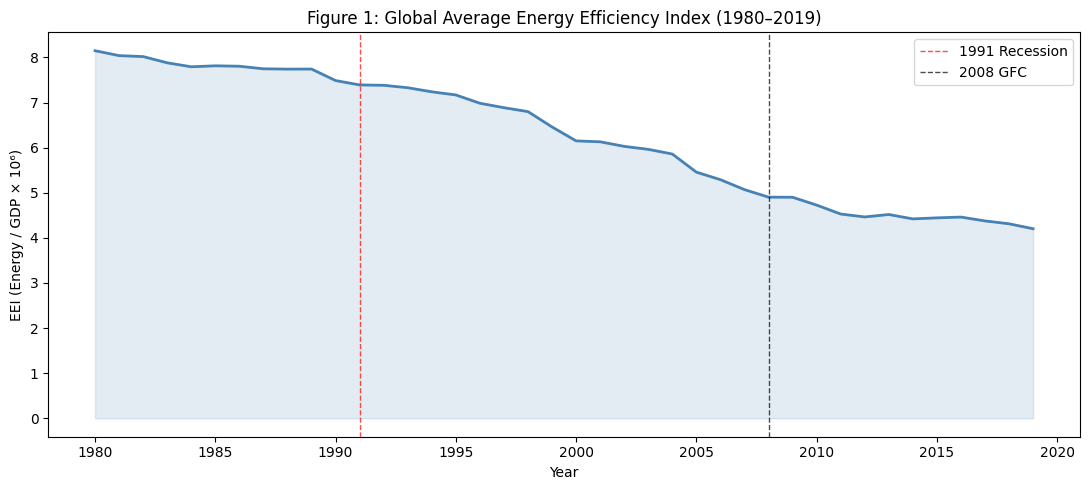

In [513]:
global_avg = global_df.groupby('year')['eei'].mean().reset_index()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(global_avg['year'], global_avg['eei'], color='steelblue', linewidth=2)
ax.fill_between(global_avg['year'], global_avg['eei'], alpha=0.15, color='steelblue')
ax.axvline(x=1991, label = '1991 Recession', linestyle = '--', color='red', linewidth=1, alpha=0.7)
ax.axvline(x=2008, label = '2008 GFC', linestyle = '--', color='black', linewidth=1, alpha=0.7)
ax.set_title('Figure 1: Global Average Energy Efficiency Index (1980–2019)')
ax.set_xlabel('Year')
ax.set_ylabel('EEI (Energy / GDP × 10⁶)')
ax.legend()
plt.tight_layout()
plt.show()

### Part 1: Q2

In [514]:
summary_group = global_df.groupby('development_status')['eei'].agg(['mean','median','std','min','max']).round(4)
print("\nTable 2: EEI Summary Statistics by Development Status")
print(summary_group.to_string())


Table 2: EEI Summary Statistics by Development Status
                      mean  median     std     min      max
development_status                                         
Developed           7.2891  6.5099  3.1437  2.5436  19.3440
Developing          5.1083  4.3831  2.8940  0.9682  16.5338


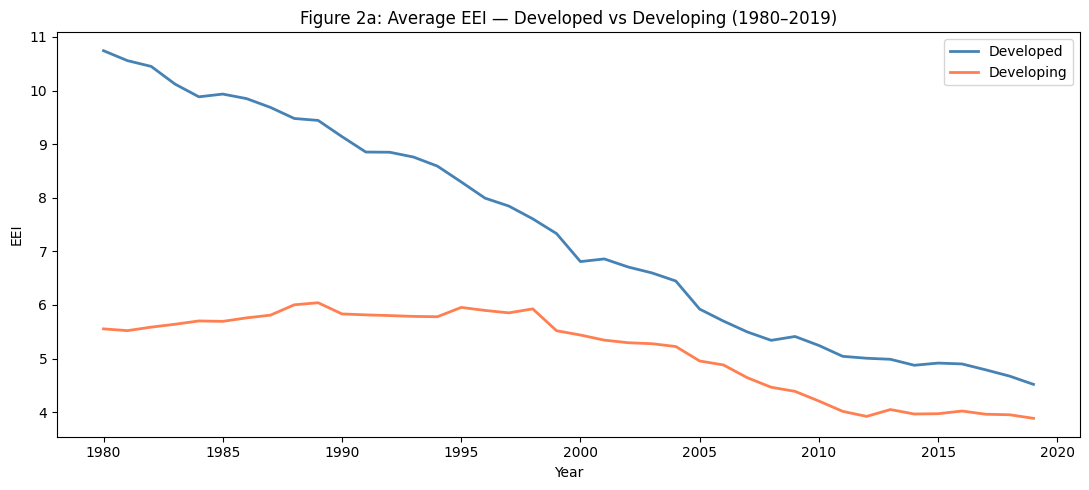

In [515]:
group_avg = global_df.groupby(['year','development_status'])['eei'].mean().reset_index()

plt.figure(figsize=(11, 5))
for status, color in zip(['Developed', 'Developing'], ['steelblue', 'coral']):
    sub = group_avg[group_avg['development_status'] == status]
    plt.plot(sub['year'], sub['eei'], label=status, color=color, linewidth=2)
plt.title('Figure 2a: Average EEI — Developed vs Developing (1980–2019)')
plt.xlabel('Year')
plt.ylabel('EEI')
plt.legend()
plt.tight_layout()
plt.show()

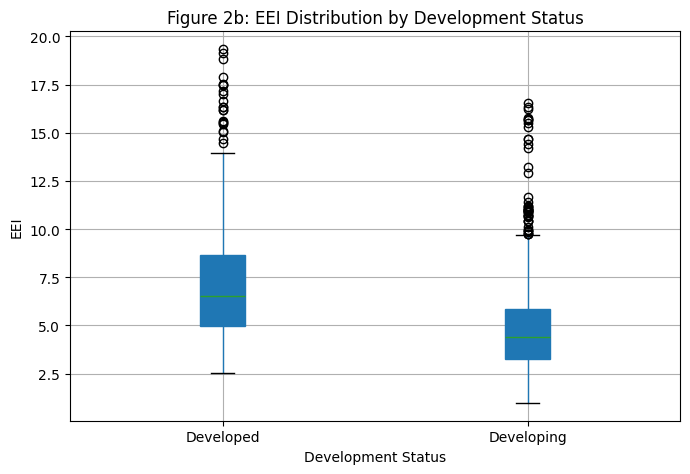

In [516]:
fig, ax = plt.subplots(figsize=(7, 5))
global_df.boxplot(column='eei', by='development_status', ax=ax, patch_artist=True)
plt.title(f'Figure 2b: EEI Distribution by Development Status')
plt.suptitle('')
plt.xlabel('Development Status')
plt.ylabel('EEI')
plt.tight_layout()
plt.show()

In [517]:
global_df = global_df.copy()
global_df['developed_dummy'] = np.where(
    global_df['development_status'] == 'Developed', 1, 0
)

Y = global_df['log_eei']
X = sm.add_constant(global_df['developed_dummy'])
model_q2 = sm.OLS(Y, X).fit(cov_type='HC3')
print(model_q2.summary())

                            OLS Regression Results                            
Dep. Variable:                log_eei   R-squared:                       0.163
Model:                            OLS   Adj. R-squared:                  0.162
Method:                 Least Squares   F-statistic:                     208.6
Date:                Thu, 07 May 2026   Prob (F-statistic):           2.25e-43
Time:                        02:07:34   Log-Likelihood:                -705.30
No. Observations:                1083   AIC:                             1415.
Df Residuals:                    1081   BIC:                             1425.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               1.4933      0.022     

### Part 1: Q3

In [518]:
latest_year = global_df['year'].max()
latest = global_df[global_df['year'] == latest_year].copy()
uk_eei = latest[latest['country_name'] == 'United Kingdom']['eei'].values[0]
uk_rank = (latest['eei'].rank(ascending=True)[latest['country_name'] == 'United Kingdom'].values[0])

print(f"UK EEI ({latest_year}): {uk_eei:.2f}")
print(f"UK Rank: {int(uk_rank)}th out of {len(latest)} countries")

UK EEI (2019): 2.67
UK Rank: 6th out of 28 countries


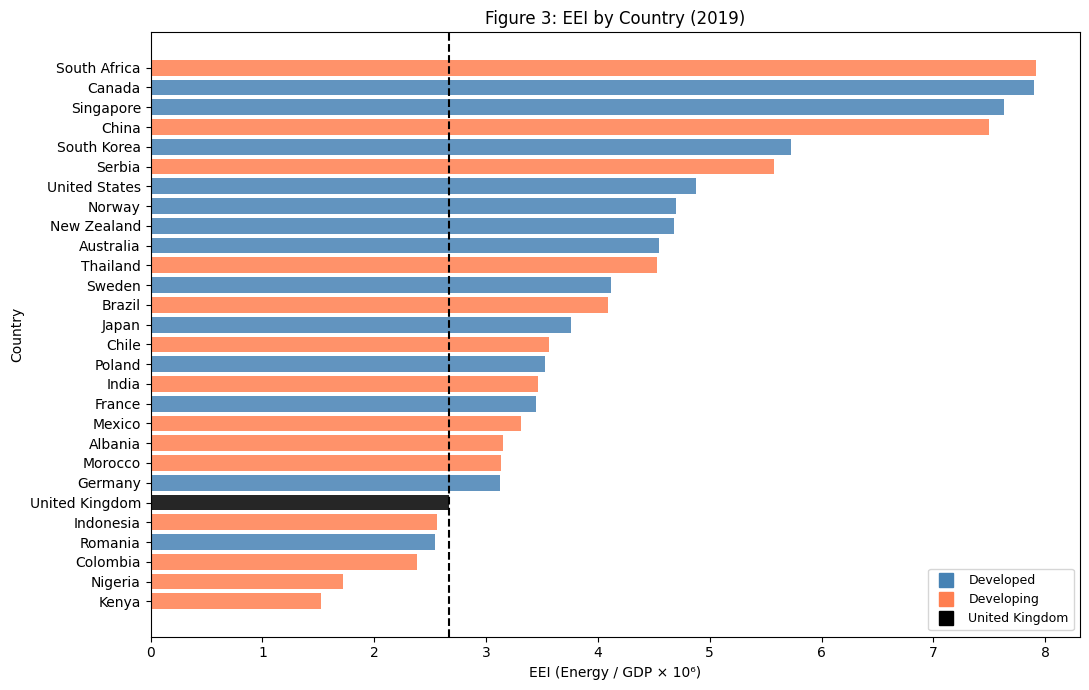

In [519]:
latest_sorted = latest.dropna(subset=['eei']).sort_values('eei')
bar_colors = ['black' if c == 'United Kingdom' else
              'steelblue' if c in developed else
              'coral'
              for c in latest_sorted['country_name']]

plt.figure(figsize=(11, 7))
plt.barh(latest_sorted['country_name'], latest_sorted['eei'],
         color=bar_colors, alpha=0.85)
plt.axvline(uk_eei, color='black', linestyle='--', linewidth=1.5,)
plt.title(f'Figure 3: EEI by Country ({latest_year})', fontsize=12)
plt.xlabel('EEI (Energy / GDP × 10⁶)')
plt.ylabel('Country')

legend_handles = [
    plt.plot([], [], 's', color='steelblue', label='Developed', markersize=10)[0],
    plt.plot([], [], 's', color='coral', label='Developing', markersize=10)[0],
    plt.plot([], [], 's', color='black', label='United Kingdom', markersize=10)[0]
]
plt.legend(handles=legend_handles, fontsize=9)
plt.tight_layout()
plt.show()

### Part 1: Q4

In [520]:
REGRESSORS = ['log_gdp_per_capita', 'industry_share_gdp',
              'renewables_share', 'trade_openness']

REGRESSOR_LABELS = {
    'log_gdp_per_capita':  'Log GDP per Capita',
    'industry_share_gdp':  'Industry Share of GDP (%)',
    'renewables_share':    'Renewable Energy Share (%)',
    'trade_openness':      'Trade Openness (% of GDP)',
}

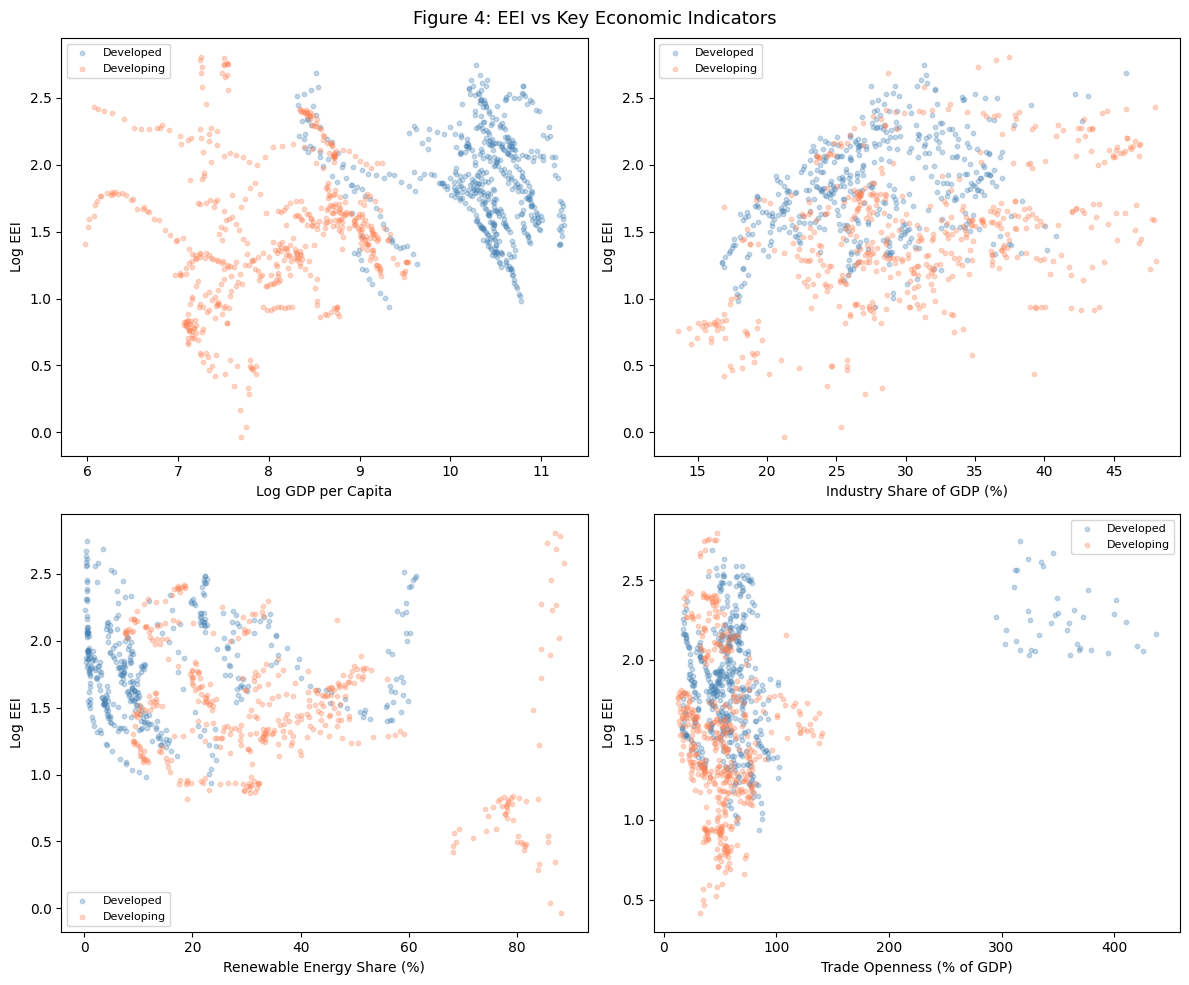

In [521]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(REGRESSORS):
    for status, color in zip(['Developed', 'Developing'], ['steelblue', 'coral']):
        sub = global_df[global_df['development_status'] == status].dropna(subset=[col, 'log_eei'])
        axes[i].scatter(sub[col], sub['log_eei'], alpha=0.3, s=10, color=color, label=status)
    axes[i].set_xlabel(REGRESSOR_LABELS[col])
    axes[i].set_ylabel('Log EEI')
    axes[i].legend(fontsize=8)
plt.suptitle('Figure 4: EEI vs Key Economic Indicators', fontsize=13)
plt.tight_layout()
plt.show()

In [522]:
sub_full = global_df.dropna(subset=['log_eei'] + REGRESSORS).reset_index(drop=True)
country_effects = pd.get_dummies(sub_full['country_name'], drop_first=True).astype(int)
year_effects    = pd.get_dummies(sub_full['year'],         drop_first=True).astype(int)

Y = sub_full['log_eei']
X = pd.concat([sub_full[REGRESSORS], country_effects, year_effects], axis=1)
X = sm.add_constant(X)
model_full = sm.OLS(Y, X).fit(cov_type='HC3')
print(model_full.summary2().tables[1].loc[['const'] + REGRESSORS].round(4))

                     Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const               3.7528    0.3899  9.6259  0.0000  2.9887  4.5169
log_gdp_per_capita -0.1842    0.0446 -4.1351  0.0000 -0.2716 -0.0969
industry_share_gdp -0.0008    0.0030 -0.2626  0.7928 -0.0067  0.0051
renewables_share   -0.0150    0.0019 -7.8168  0.0000 -0.0188 -0.0113
trade_openness      0.0014    0.0007  2.0444  0.0409  0.0001  0.0028


In [523]:
sub_dev = global_df[global_df['development_status'] == 'Developed'].dropna(subset=['log_eei'] + REGRESSORS).reset_index(drop=True)
country_effects = pd.get_dummies(sub_dev['country_name'], drop_first=True).astype(int)
year_effects    = pd.get_dummies(sub_dev['year'],         drop_first=True).astype(int)

Y = sub_dev['log_eei']
X = pd.concat([sub_dev[REGRESSORS], country_effects, year_effects], axis=1)
X = sm.add_constant(X)
model_dev = sm.OLS(Y, X).fit(cov_type='HC3')
print(model_dev.summary2().tables[1].loc[['const'] + REGRESSORS].round(4))

                     Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const               4.3523    1.2704  3.4259  0.0006  1.8624  6.8423
log_gdp_per_capita -0.1686    0.1230 -1.3703  0.1706 -0.4096  0.0725
industry_share_gdp -0.0126    0.0055 -2.2913  0.0219 -0.0234 -0.0018
renewables_share   -0.0222    0.0037 -5.9869  0.0000 -0.0295 -0.0149
trade_openness      0.0005    0.0006  0.7128  0.4760 -0.0008  0.0017


In [524]:
sub_devg = global_df[global_df['development_status'] == 'Developing'].dropna(subset=['log_eei'] + REGRESSORS).reset_index(drop=True)
country_effects = pd.get_dummies(sub_devg['country_name'], drop_first=True).astype(int)
year_effects    = pd.get_dummies(sub_devg['year'],         drop_first=True).astype(int)

Y = sub_devg['log_eei']
X = pd.concat([sub_devg[REGRESSORS], country_effects, year_effects], axis=1)
X = sm.add_constant(X)
model_devg = sm.OLS(Y, X).fit(cov_type='HC3')
print(model_devg.summary2().tables[1].loc[['const'] + REGRESSORS].round(4))

                     Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const               1.5267    0.3452  4.4223  0.0000  0.8501  2.2033
log_gdp_per_capita -0.0162    0.0388 -0.4184  0.6757 -0.0923  0.0598
industry_share_gdp  0.0004    0.0025  0.1579  0.8745 -0.0044  0.0052
renewables_share    0.0015    0.0019  0.7809  0.4349 -0.0022  0.0052
trade_openness      0.0028    0.0008  3.5013  0.0005  0.0012  0.0043


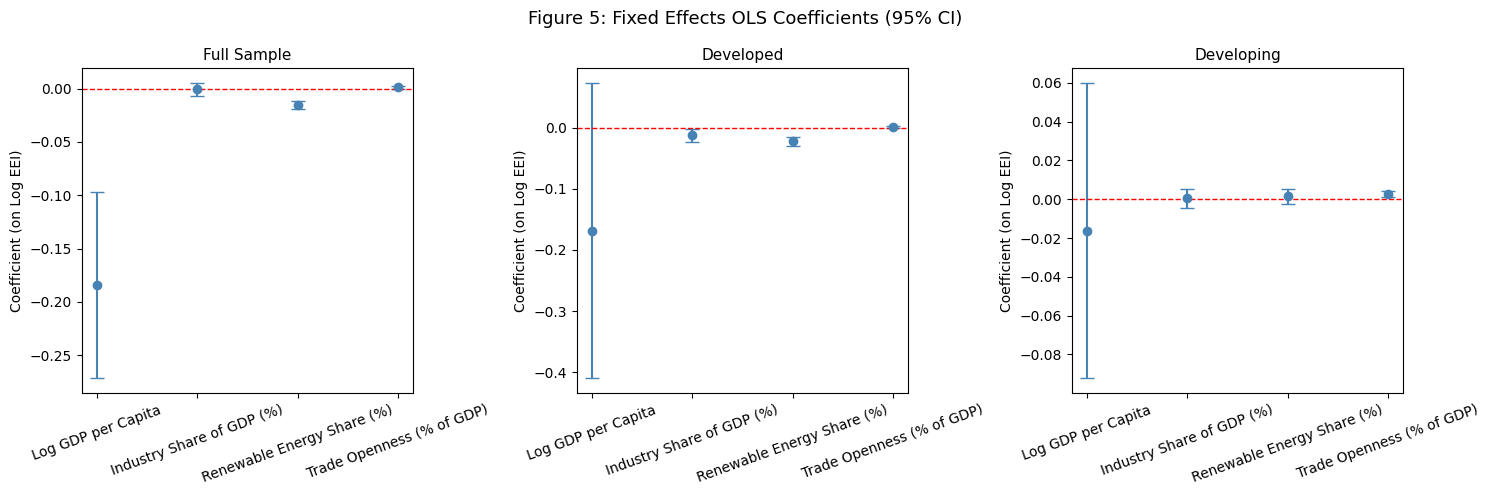

In [525]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, model, label in zip(
    axes,
    [model_full, model_dev, model_devg],
    ['Full Sample', 'Developed', 'Developing']
):
    coefs = model.params[REGRESSORS].values
    ses   = model.bse[REGRESSORS].values
    names = [REGRESSOR_LABELS[v] for v in REGRESSORS]

    ax.errorbar(names, y=coefs, yerr=1.96*ses,
                fmt='o', capsize=5, color='steelblue', linewidth=1.5)
    ax.axhline(y=0, color='red', linestyle='dashed', linewidth=1)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Coefficient (on Log EEI)')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Figure 5: Fixed Effects OLS Coefficients (95% CI)', fontsize=13)
plt.tight_layout()
plt.show()

### Part 1: Q6

In [526]:
global_ts = global_df.groupby('year').agg(
    avg_eei=('eei', 'mean'),
    total_co2=('co2_emissions', 'sum')
).reset_index()

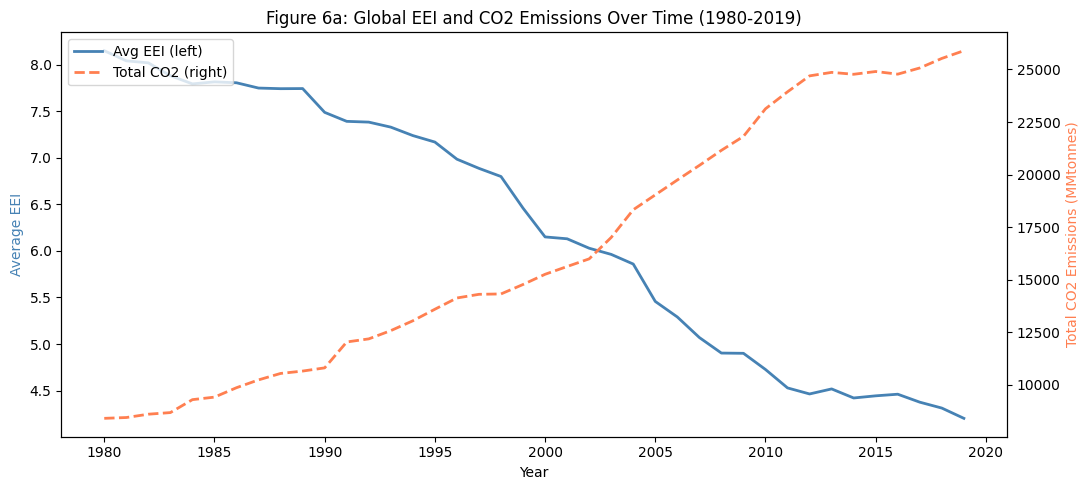

In [527]:
fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.plot(global_ts['year'], global_ts['avg_eei'], color='steelblue', linewidth=2, label='Avg EEI (left)')
ax2.plot(global_ts['year'], global_ts['total_co2'], color='coral', linewidth=2, linestyle='--', label='Total CO2 (right)')
ax1.set_xlabel('Year')
ax1.set_ylabel('Average EEI', color='steelblue')
ax2.set_ylabel('Total CO2 Emissions (MMtonnes)', color='coral')
ax1.set_title('Figure 6a: Global EEI and CO2 Emissions Over Time (1980-2019)', fontsize=12)

lines  = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')
plt.tight_layout()
plt.show()


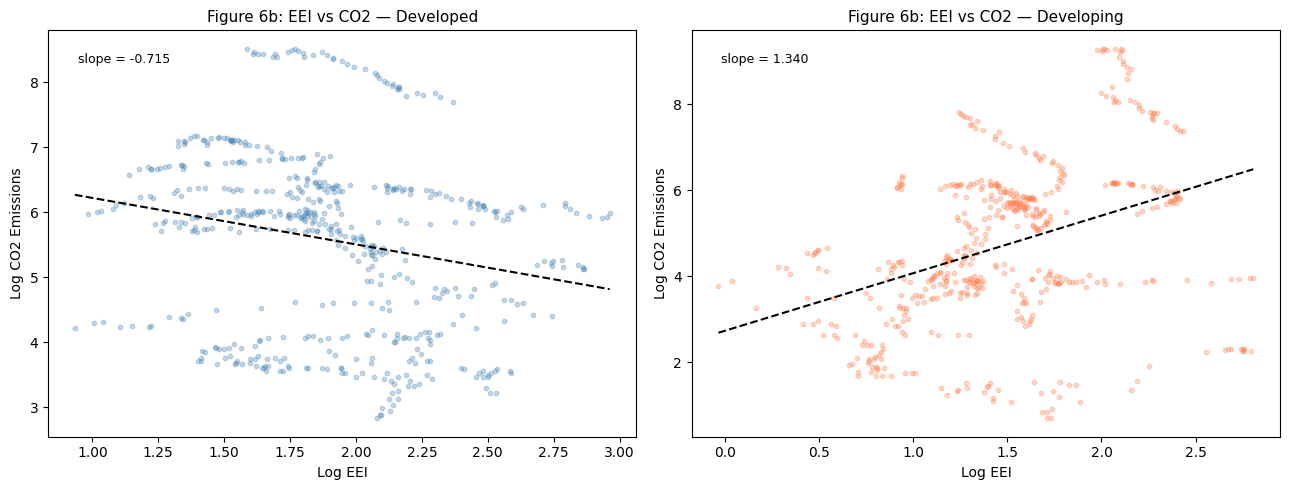

In [528]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, status, color in zip(axes, ['Developed', 'Developing'], ['steelblue', 'coral']):
    sub = global_df[global_df['development_status'] == status].dropna(subset=['log_eei', 'log_co2_emissions'])
    ax.scatter(sub['log_eei'], sub['log_co2_emissions'], alpha=0.3, s=10, color=color)
    m, b = np.polyfit(sub['log_eei'], sub['log_co2_emissions'], 1)
    x_line = np.linspace(sub['log_eei'].min(), sub['log_eei'].max(), 100)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--')
    ax.set_xlabel('Log EEI')
    ax.set_ylabel('Log CO2 Emissions')
    ax.set_title(f'Figure 6b: EEI vs CO2 — {status}', fontsize=11)
    ax.text(0.05, 0.92, f'slope = {m:.3f}', transform=ax.transAxes, fontsize=9)
plt.tight_layout()
plt.show()

In [529]:
sub_full = global_df.dropna(subset=['log_co2_emissions', 'log_eei']).reset_index(drop=True)
country_effects = pd.get_dummies(sub_full['country_name'], drop_first=True).astype(int)
year_effects    = pd.get_dummies(sub_full['year'],         drop_first=True).astype(int)

Y = sub_full['log_co2_emissions']
X = pd.concat([sub_full[['log_eei']], country_effects, year_effects], axis=1)
X = sm.add_constant(X)
model_co2_full = sm.OLS(Y, X).fit(cov_type='HC3')
print("\nFixed Effects OLS — CO2 ~ EEI Full Sample")
print(f"N={model_co2_full.nobs:.0f} | R²={model_co2_full.rsquared:.4f}")
print(model_co2_full.summary2().tables[1].loc[['const', 'log_eei']].round(4))


Fixed Effects OLS — CO2 ~ EEI Full Sample
N=1083 | R²=0.9777
          Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
const   -0.4275    0.1750  -2.4429  0.0146 -0.7705 -0.0845
log_eei  0.7303    0.0696  10.4918  0.0000  0.5939  0.8667


In [530]:
sub_dev = global_df[global_df['development_status'] == 'Developed'].dropna(subset=['log_co2_emissions', 'log_eei']).reset_index(drop=True)
country_effects = pd.get_dummies(sub_dev['country_name'], drop_first=True).astype(int)
year_effects    = pd.get_dummies(sub_dev['year'],         drop_first=True).astype(int)

Y = sub_dev['log_co2_emissions']
X = pd.concat([sub_dev[['log_eei']], country_effects, year_effects], axis=1)
X = sm.add_constant(X)
model_co2_dev = sm.OLS(Y, X).fit(cov_type='HC3')
print("\nFixed Effects OLS — CO2 ~ EEI Developed")
print(f"N={model_co2_dev.nobs:.0f} | R²={model_co2_dev.rsquared:.4f}")
print(model_co2_dev.summary2().tables[1].loc[['const', 'log_eei']].round(4))


Fixed Effects OLS — CO2 ~ EEI Developed
N=549 | R²=0.9810
          Coef.  Std.Err.        z  P>|z|  [0.025  0.975]
const    3.2341    0.1857  17.4197    0.0  2.8702  3.5980
log_eei  1.0331    0.0602  17.1609    0.0  0.9151  1.1511


In [531]:
sub_devg = global_df[global_df['development_status'] == 'Developing'].dropna(subset=['log_co2_emissions', 'log_eei']).reset_index(drop=True)
country_effects = pd.get_dummies(sub_devg['country_name'], drop_first=True).astype(int)
year_effects    = pd.get_dummies(sub_devg['year'],         drop_first=True).astype(int)

Y = sub_devg['log_co2_emissions']
X = pd.concat([sub_devg[['log_eei']], country_effects, year_effects], axis=1)
X = sm.add_constant(X)
model_co2_devg = sm.OLS(Y, X).fit(cov_type='HC3')
print("\nFixed Effects OLS — CO2 ~ EEI Developing")
print(f"N={model_co2_devg.nobs:.0f} | R²={model_co2_devg.rsquared:.4f}")
print(model_co2_devg.summary2().tables[1].loc[['const', 'log_eei']].round(4))


Fixed Effects OLS — CO2 ~ EEI Developing
N=534 | R²=0.9806
          Coef.  Std.Err.       z   P>|z|  [0.025  0.975]
const   -0.1014    0.2013 -0.5037  0.6145 -0.4958  0.2931
log_eei  0.5188    0.0884  5.8679  0.0000  0.3455  0.6921


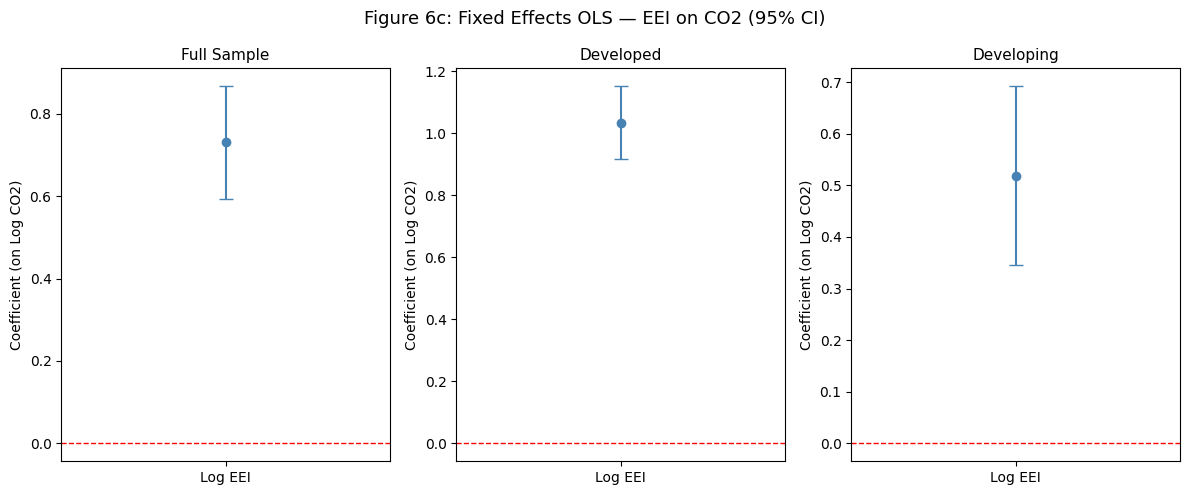

In [532]:
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
for ax, model, label in zip(
    axes,
    [model_co2_full, model_co2_dev, model_co2_devg],
    ['Full Sample', 'Developed', 'Developing']
):
    ax.errorbar(['Log EEI'], y=[model.params['log_eei']],
                yerr=1.96 * model.bse['log_eei'],
                fmt='o', capsize=5, color='steelblue', linewidth=1.5)
    ax.axhline(y=0, color='red', linestyle='dashed', linewidth=1)
    ax.set_title(label, fontsize=11)
    ax.set_ylabel('Coefficient (on Log CO2)')

plt.suptitle('Figure 6c: Fixed Effects OLS — EEI on CO2 (95% CI)', fontsize=13)
plt.tight_layout()
plt.show()

### Part 2: Q1

In [533]:
regional_df = regional_df.sort_values(by='energy_efficiency_band', ascending=True)

In [534]:
regional_gdf = gpd.GeoDataFrame(
    regional_df,
    geometry=regional_df['geometry']
)

In [535]:
regional_df

,FID,local_authority_district_code,local_authority_district_name,local_authority_district_welsh_name,BNG_E,BNG_N,Long,Lat,GlobalID,geometry,region_code,region_name,energy_efficiency_score,period,environmental_impact_score,energy_efficiency_band,environmental_impact_band
196,101,E07000077,Uttlesford,,557833,228863,0.294499,51.93590,d34d0092-ed36-4c52-b830-beb7ff7692a4,"POLYGON ((0.27701 52.09237, 0.27705 52.09235, ...",E12000006,East of England,69.0,2020-21,66.0,C,D
244,125,E07000105,Ashford,,597640,140644,0.823374,51.13096,3f902090-5b4b-4351-81a9-cf1596a04e6c,"POLYGON ((0.95745 51.26886, 0.95815 51.2685, 0...",E12000008,South East,69.0,2020-21,67.0,C,D
556,281,E09000018,Hounslow,,512737,174959,-0.378550,51.46238,8848da5b-2283-41dd-aab5-3cf8c7d75077,"MULTIPOLYGON (((-0.32622 51.46232, -0.32624 51...",E12000007,London,69.0,2020-21,66.0,C,D
557,281,E09000018,Hounslow,,512737,174959,-0.378550,51.46238,8848da5b-2283-41dd-aab5-3cf8c7d75077,"MULTIPOLYGON (((-0.32622 51.46232, -0.32624 51...",E12000007,London,69.0,2021-22,66.0,C,D
558,282,E09000019,Islington,,531160,184645,-0.109890,51.54546,eca02a8b-5688-4e81-ad3e-58f419d256cf,"POLYGON ((-0.11927 51.57509, -0.1192 51.57499,...",E12000007,London,71.0,2020-21,71.0,C,C
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,50,E06000053,Isles of Scilly,,91327,11447,-6.302170,49.92332,f1d0ab22-8c27-4351-baaa-1f7a9a19303c,"MULTIPOLYGON (((-6.39952 49.86527, -6.39941 49...",E12000009,South West,47.0,2021-22,40.0,E,E
118,60,E06000063,Cumberland,,315777,533120,-3.307970,54.68606,f71817f9-af31-48d3-8c7f-437666980195,"MULTIPOLYGON (((-3.25616 54.21552, -3.25618 54...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
119,61,E06000064,Westmorland and Furness,,353889,510941,-2.713360,54.49170,3e1c6f1d-3e44-4cc0-9360-67bd97d4d48c,"MULTIPOLYGON (((-3.20111 54.0641, -3.2013 54.0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
120,62,E06000065,North Yorkshire,,429508,466514,-1.550330,54.09370,12097e42-d342-4f3c-9f2b-e4b9b725b24a,"MULTIPOLYGON (((-1.00647 53.88871, -1.00623 53...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [536]:
latest_epc = regional_df[regional_df['period'] == '2021-22'].copy()
latest_epc_gdf = regional_gdf[regional_gdf['period'] == '2021-22'].copy()

In [537]:
region_summary_ee = (latest_epc.groupby('region_name')['energy_efficiency_score']
                     .agg(['mean', 'median', 'std', 'min', 'max'])
                     .round(2)
                     .sort_values('median', ascending=False))
print("\nTable 3: Energy Efficiency Scores by Region (2021-22)")
print(region_summary_ee.to_string())


Table 3: Energy Efficiency Scores by Region (2021-22)
                           mean  median   std   min   max
region_name                                              
London                    68.30    68.0  2.90  65.0  77.0
East of England           66.96    67.0  1.99  62.0  71.0
South East                67.39    67.0  1.59  65.0  71.0
North East                66.92    67.0  0.90  65.0  68.0
East Midlands             65.94    66.0  1.47  63.0  70.0
North West                65.76    66.0  2.40  60.0  72.0
South West                65.50    66.0  4.13  47.0  69.0
West Midlands             66.20    66.0  1.47  63.0  69.0
Yorkshire and The Humber  65.29    66.0  1.64  62.0  67.0
Wales                     64.45    65.5  3.08  58.0  68.0


In [538]:
region_summary_ei = (latest_epc.groupby('region_name')['environmental_impact_score']
                     .agg(['mean', 'median', 'std', 'min', 'max'])
                     .round(2)
                     .sort_values('median', ascending=False))
print("\nTable 4: Environmental Impact Scores by Region (2021-22)")
print(region_summary_ei.to_string())


Table 4: Environmental Impact Scores by Region (2021-22)
                           mean  median   std   min   max
region_name                                              
London                    65.88    66.0  3.95  61.0  77.0
North East                64.67    65.0  1.37  62.0  67.0
South East                64.33    64.0  2.14  61.0  69.0
East of England           63.64    64.0  2.92  57.0  70.0
East Midlands             63.00    63.0  2.00  59.0  68.0
North West                62.73    63.0  3.35  55.0  71.0
South West                62.08    63.0  5.07  40.0  67.0
West Midlands             62.97    63.0  1.97  59.0  68.0
Yorkshire and The Humber  62.29    62.5  2.55  57.0  65.0
Wales                     60.86    62.0  4.27  52.0  66.0


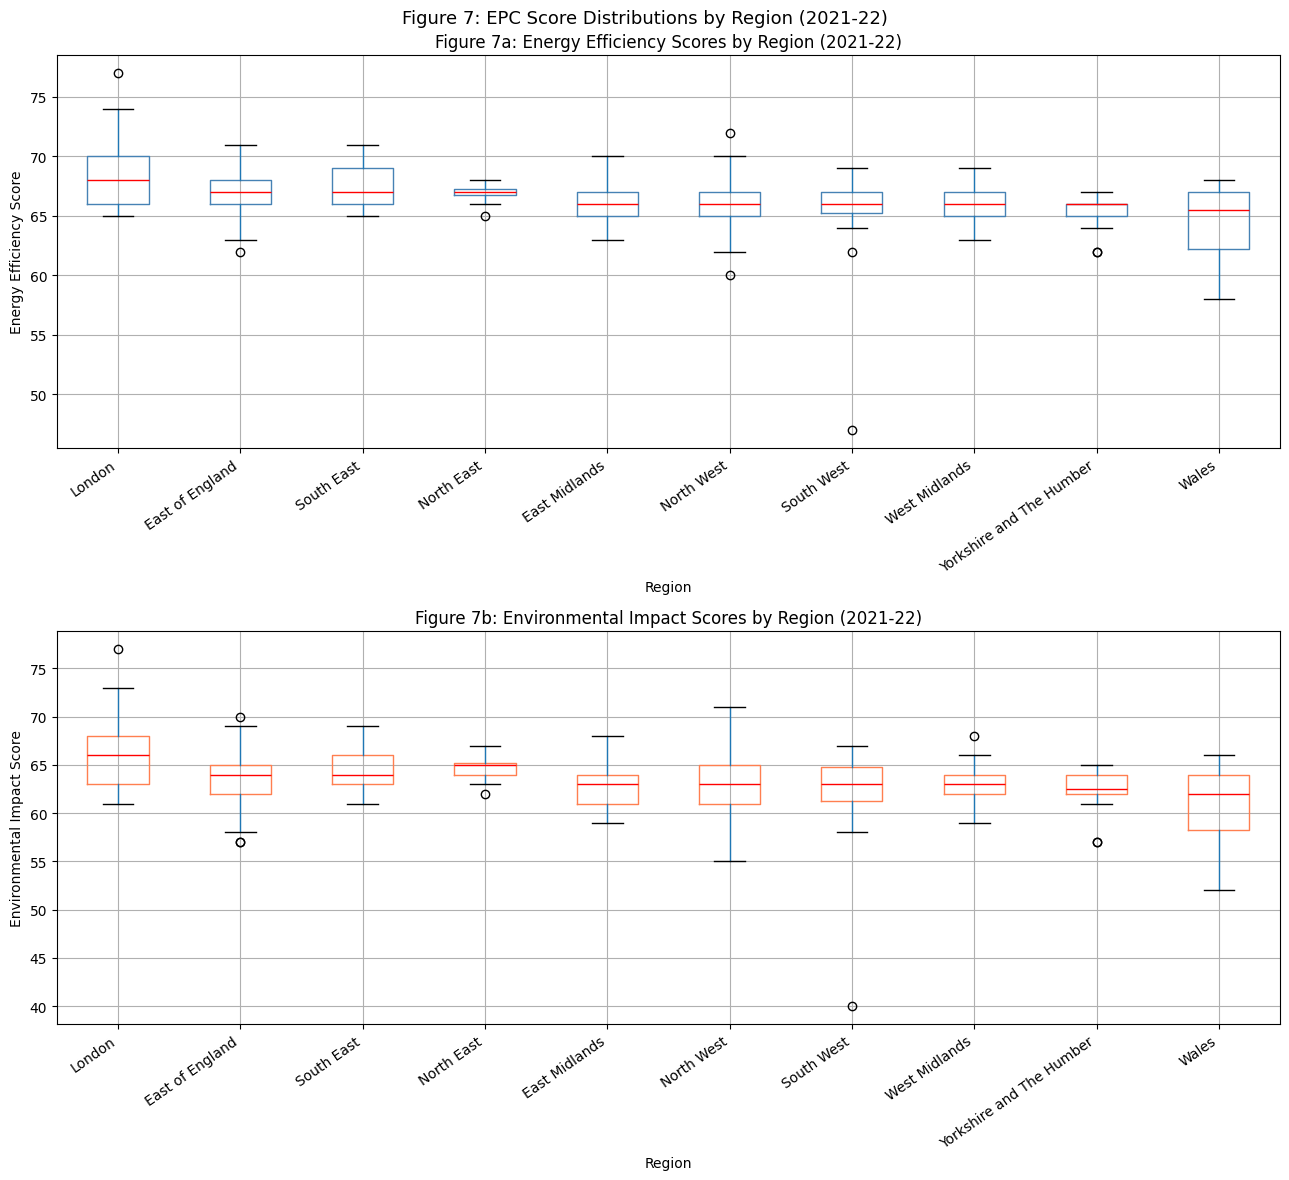

In [539]:
regions_ordered = (latest_epc.groupby('region_name', observed=False)['energy_efficiency_score']
                   .median().sort_values(ascending=False).index.tolist())

latest_epc['region_name'] = pd.Categorical(latest_epc['region_name'], categories=regions_ordered, ordered=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 12))

latest_epc.boxplot(column='energy_efficiency_score', by='region_name',
                   ax=axes[0],
                   boxprops=dict(color='steelblue'),
                   medianprops=dict(color='red'))
axes[0].set_title('Figure 7a: Energy Efficiency Scores by Region (2021-22)', fontsize=12)
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Energy Efficiency Score')
axes[0].tick_params(axis='x', rotation=35)
plt.sca(axes[0])
plt.xticks(ha='right')
plt.suptitle('')

latest_epc.boxplot(column='environmental_impact_score', by='region_name',
                   ax=axes[1],
                   boxprops=dict(color='coral'),
                   medianprops=dict(color='red'))
axes[1].set_title('Figure 7b: Environmental Impact Scores by Region (2021-22)', fontsize=12)
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Environmental Impact Score')
axes[1].tick_params(axis='x', rotation=35)
plt.sca(axes[1])
plt.xticks(ha='right')
plt.suptitle('')

plt.suptitle('Figure 7: EPC Score Distributions by Region (2021-22)', fontsize=13)
plt.tight_layout()
plt.show()

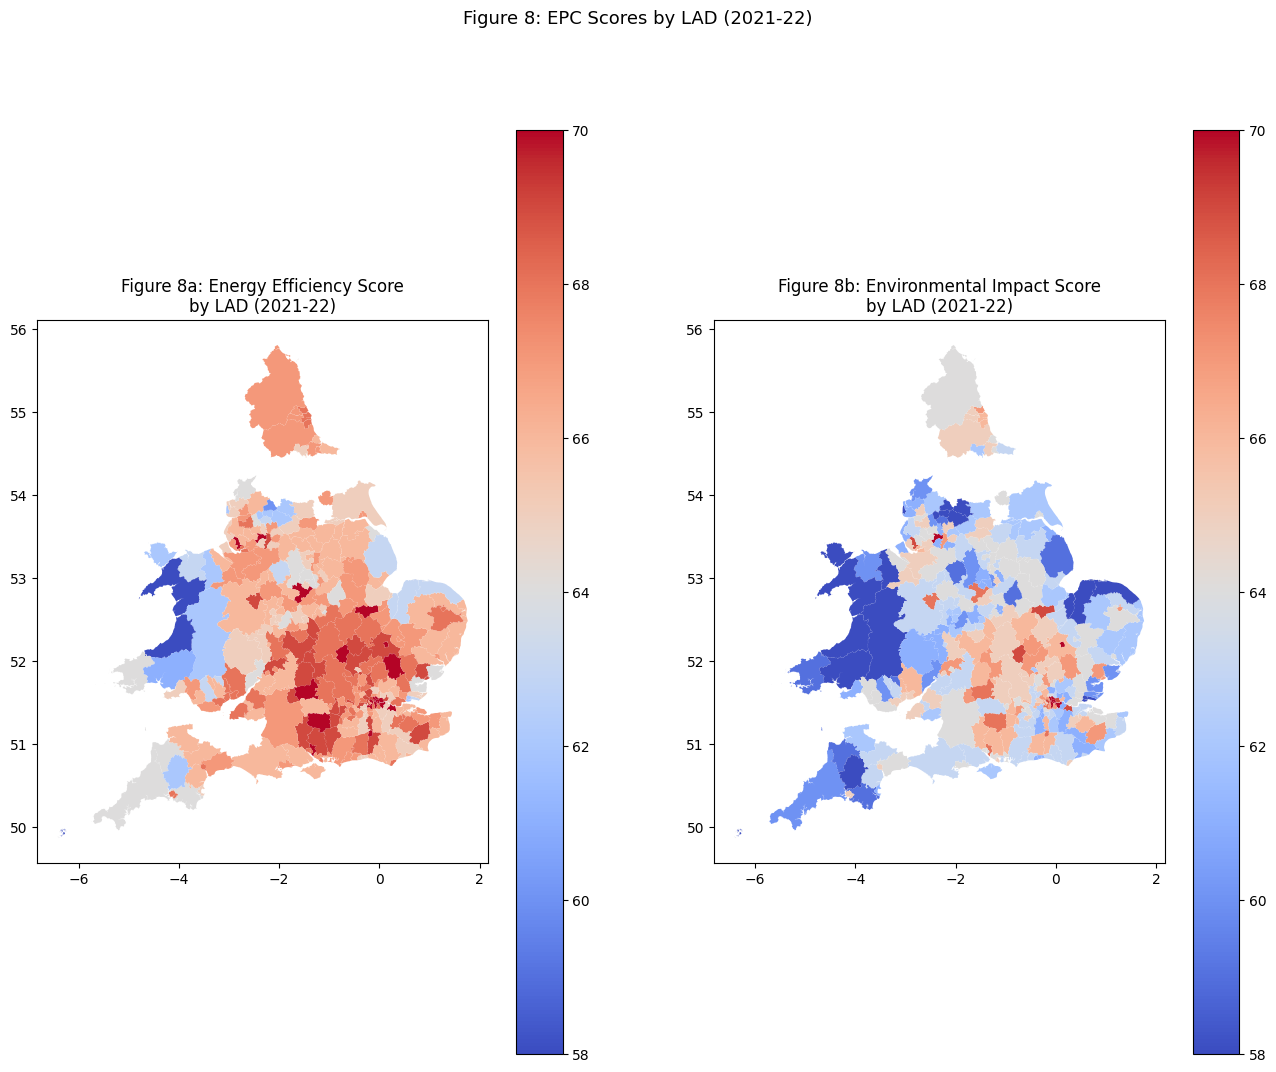

In [540]:
fig, axes = plt.subplots(1, 2, figsize=(16, 12))

latest_epc_gdf.plot(column='energy_efficiency_score',
                    cmap='coolwarm',
                    legend=True,
                    ax=axes[0],
                    missing_kwds={'color': 'lightgrey'},
                    vmin = 58,
                    vmax = 70)
axes[0].set_title('Figure 8a: Energy Efficiency Score\nby LAD (2021-22)', fontsize=12)

latest_epc_gdf.plot(column='environmental_impact_score',
                    cmap='coolwarm',
                    legend=True,
                    ax=axes[1],
                    missing_kwds={'color': 'lightgrey'},
                    vmin = 58,
                    vmax = 70)
axes[1].set_title('Figure 8b: Environmental Impact Score\nby LAD (2021-22)', fontsize=12)

plt.suptitle('Figure 8: EPC Scores by LAD (2021-22)', fontsize=13)
plt.show()

### Part 2: Q2

In [541]:
regional_df['energy_efficiency_score']    = pd.to_numeric(regional_df['energy_efficiency_score'],    errors='coerce')
regional_df['environmental_impact_score'] = pd.to_numeric(regional_df['environmental_impact_score'], errors='coerce')

In [542]:
epc_pivot_ee = regional_df.pivot_table(
    index=['local_authority_district_code', 'local_authority_district_name', 'region_name'],
    columns='period', values='energy_efficiency_score'
).reset_index()
epc_pivot_ee.columns.name = None
epc_pivot_ee['change_ee'] = epc_pivot_ee['2021-22'] - epc_pivot_ee['2020-21']

epc_pivot_ei = regional_df.pivot_table(
    index=['local_authority_district_code', 'local_authority_district_name', 'region_name'],
    columns='period', values='environmental_impact_score'
).reset_index()
epc_pivot_ei.columns.name = None
epc_pivot_ei['change_ei'] = epc_pivot_ei['2021-22'] - epc_pivot_ei['2020-21']
epc_pivot_ee

,local_authority_district_code,local_authority_district_name,region_name,2020-21,2021-22,change_ee
0,E06000001,Hartlepool,North East,66.0,66.0,0.0
1,E06000002,Middlesbrough,North East,67.0,67.0,0.0
2,E06000003,Redcar and Cleveland,North East,65.0,66.0,1.0
3,E06000004,Stockton-on-Tees,North East,67.0,67.0,0.0
4,E06000005,Darlington,North East,65.0,65.0,0.0
...,...,...,...,...,...,...
309,W06000020,Torfaen,Wales,67.0,68.0,1.0
310,W06000021,Monmouthshire,Wales,66.0,68.0,2.0
311,W06000022,Newport,Wales,68.0,68.0,0.0
312,W06000023,Powys,Wales,61.0,62.0,1.0


In [543]:
print(f"\nEnergy Efficiency Score Changes (2020-21 to 2021-22):")
print(f"  Mean change:    {epc_pivot_ee['change_ee'].mean():.3f}")
print(f"  Improved LADs:  {(epc_pivot_ee['change_ee'] > 0).sum()}")
print(f"  Declined LADs:  {(epc_pivot_ee['change_ee'] < 0).sum()}")
print(f"  Unchanged LADs: {(epc_pivot_ee['change_ee'] == 0).sum()}")


Energy Efficiency Score Changes (2020-21 to 2021-22):
  Mean change:    0.787
  Improved LADs:  207
  Declined LADs:  12
  Unchanged LADs: 95


In [544]:
region_change_ee = (epc_pivot_ee.groupby('region_name')['change_ee']
                 .agg(['mean', 'median', 'min', 'max'])
                 .round(3)
                 .sort_values('mean', ascending=False))
print("\nTable 5: Mean Change in Energy Efficiency Score by Region")
print(region_change_ee.to_string())


Table 5: Mean Change in Energy Efficiency Score by Region
                           mean  median  min  max
region_name                                      
West Midlands             1.100     1.0  0.0  2.0
Wales                     1.091     1.0  0.0  5.0
East of England           1.022     1.0  0.0  2.0
South East                0.906     1.0 -1.0  2.0
South West                0.808     1.0  0.0  2.0
East Midlands             0.743     1.0 -1.0  2.0
North East                0.500     0.0  0.0  2.0
London                    0.485     1.0 -5.0  2.0
North West                0.424     0.0 -1.0  2.0
Yorkshire and The Humber  0.214     0.0 -1.0  1.0


In [545]:
region_change_ei = (epc_pivot_ei.groupby('region_name')['change_ei']
                 .agg(['mean', 'median', 'min', 'max'])
                 .round(3)
                 .sort_values('mean', ascending=False))
print("\nTable 6: Mean Change in Environmental Impact Score by Region")
print(region_change_ei.to_string())


Table 6: Mean Change in Environmental Impact Score by Region
                           mean  median  min  max
region_name                                      
Wales                     1.273     1.0 -1.0  5.0
West Midlands             1.167     1.0  0.0  3.0
East of England           1.044     1.0 -1.0  3.0
South East                1.031     1.0 -1.0  3.0
South West                1.000     1.0  0.0  2.0
East Midlands             0.914     1.0 -1.0  3.0
North East                0.583     1.0 -1.0  2.0
London                    0.515     1.0 -6.0  3.0
North West                0.485     1.0 -2.0  2.0
Yorkshire and The Humber -0.143     0.0 -2.0  1.0


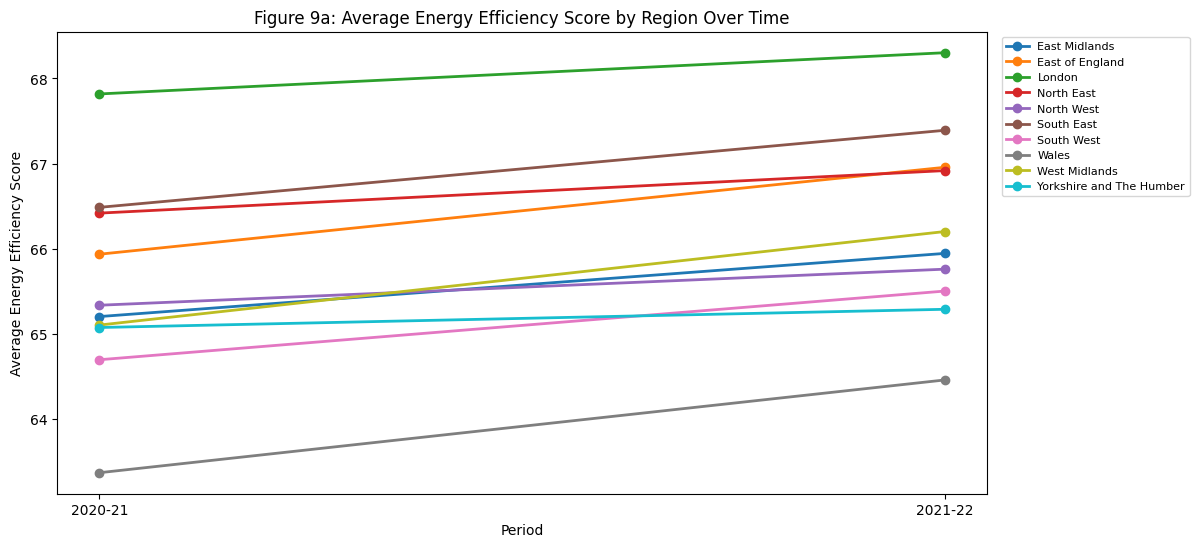

In [546]:
region_period_ee = (regional_df.groupby(['region_name', 'period'])
                 ['energy_efficiency_score'].mean().reset_index())

plt.figure(figsize=(12, 6))
for region in region_period_ee['region_name'].dropna().unique():
    sub = region_period_ee[region_period_ee['region_name'] == region]
    plt.plot(sub['period'], sub['energy_efficiency_score'],
             marker='o', linewidth=2, label=region)
plt.title('Figure 9a: Average Energy Efficiency Score by Region Over Time', fontsize=12)
plt.xlabel('Period')
plt.ylabel('Average Energy Efficiency Score')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.show()

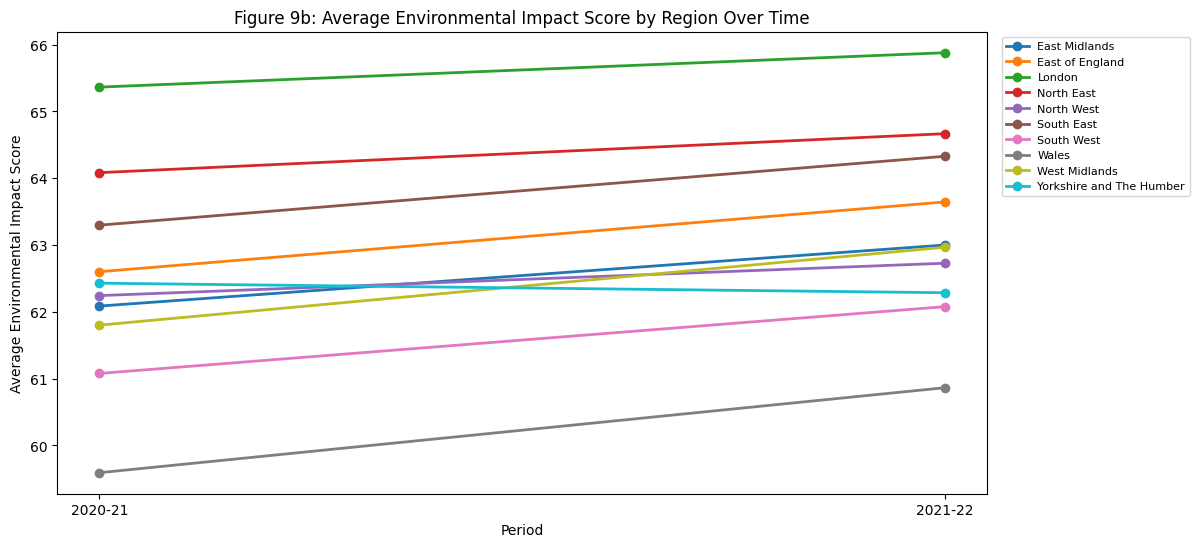

In [547]:
region_period_ei = (regional_df.groupby(['region_name', 'period'])
                 ['environmental_impact_score'].mean().reset_index())

plt.figure(figsize=(12, 6))
for region in region_period_ei['region_name'].dropna().unique():
    sub = region_period_ei[region_period_ei['region_name'] == region]
    plt.plot(sub['period'], sub['environmental_impact_score'],
             marker='o', linewidth=2, label=region)
plt.title('Figure 9b: Average Environmental Impact Score by Region Over Time', fontsize=12)
plt.xlabel('Period')
plt.ylabel('Average Environmental Impact Score')
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.show()

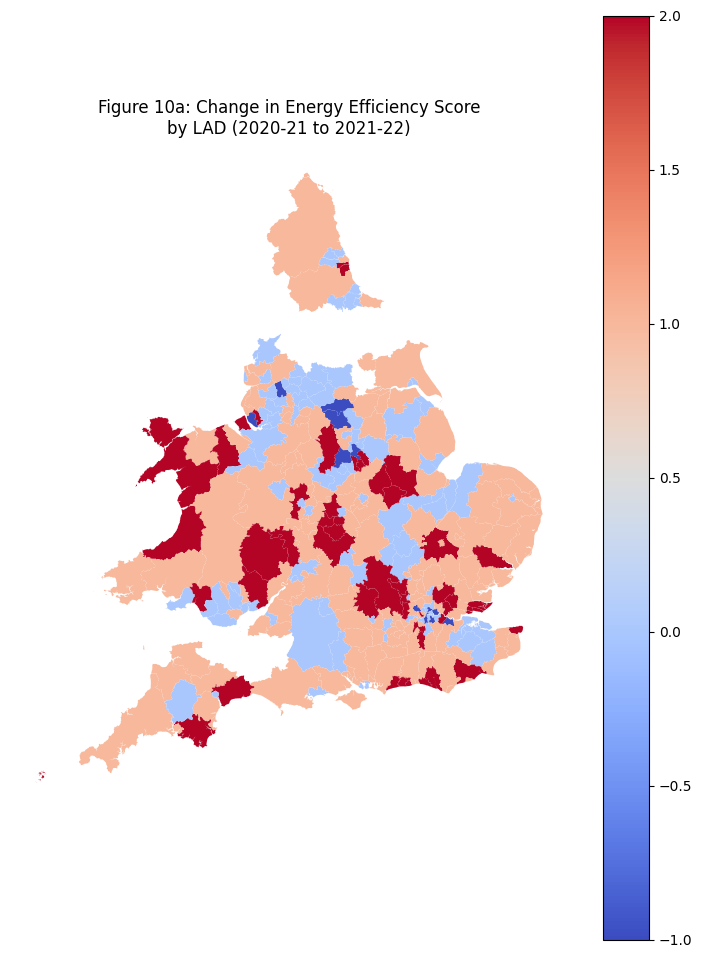

In [548]:
change_gdf_ee = regional_gdf[regional_gdf['period'] == '2021-22'].copy()
change_gdf_ee = change_gdf_ee.merge(
    epc_pivot_ee[['local_authority_district_code', 'change_ee']],
    on='local_authority_district_code', how='left'
)

fig, ax = plt.subplots(figsize=(9, 12))
change_gdf_ee.plot(column='change_ee',
                cmap='coolwarm',
                legend=True,
                missing_kwds={'color': 'lightgrey'},
                ax=ax,
                vmin = -1,
                vmax = 2)
ax.set_title('Figure 10a: Change in Energy Efficiency Score\nby LAD (2020-21 to 2021-22)', fontsize=12)
ax.axis('off')
plt.show()

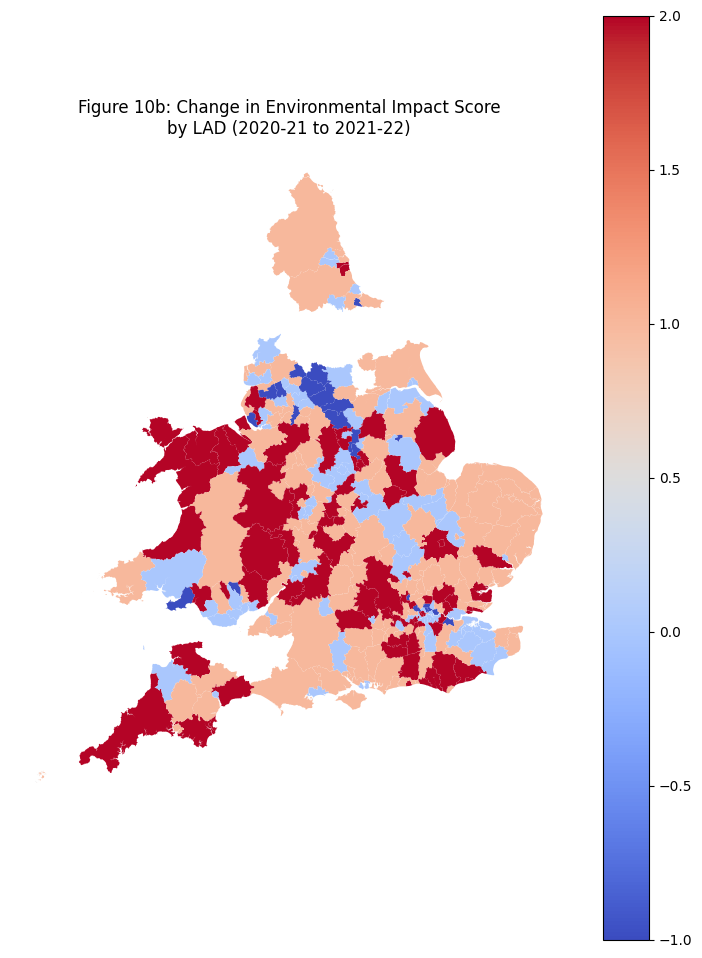

In [549]:
change_gdf_ei = regional_gdf[regional_gdf['period'] == '2021-22'].copy()
change_gdf_ei = change_gdf_ei.merge(
    epc_pivot_ei[['local_authority_district_code', 'change_ei']],
    on='local_authority_district_code', how='left'
)

fig, ax = plt.subplots(figsize=(9, 12))
change_gdf_ei.plot(column='change_ei',
                cmap='coolwarm',
                legend=True,
                missing_kwds={'color': 'lightgrey'},
                ax=ax,
                vmin = -1,
                vmax = 2)
ax.set_title('Figure 10b: Change in Environmental Impact Score\nby LAD (2020-21 to 2021-22)', fontsize=12)
ax.axis('off')
plt.show()

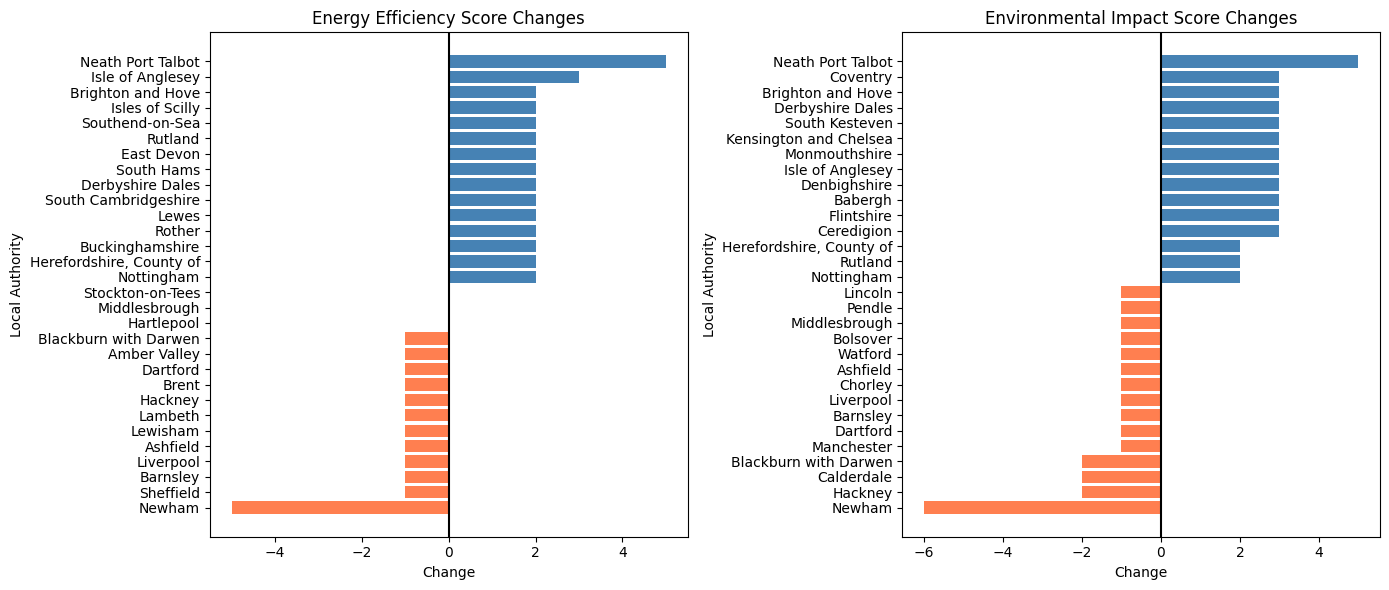

In [550]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pivot, col, title in zip(
    axes,
    [epc_pivot_ee, epc_pivot_ei],
    ['change_ee', 'change_ei'],
    ['Energy Efficiency', 'Environmental Impact']
):
    combined = pd.concat([
        pivot.nlargest(15, col),
        pivot.nsmallest(15, col)
    ]).sort_values(col)
    colors = ['steelblue' if v >= 0 else 'coral' for v in combined[col]]
    ax.barh(combined['local_authority_district_name'], combined[col], color=colors)
    ax.axvline(0, color='black')
    ax.set_title(f'{title} Score Changes')
    ax.set_xlabel('Change')
    ax.set_ylabel('Local Authority')


plt.tight_layout()
plt.show()

## End